# Imports

Treasury: DGS10
S&P500: SP500
Bitcoin: Close

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.ndimage import uniform_filter1d

from statsmodels.tsa.stattools import adfuller, acf, pacf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Optional if installed
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except Exception:
    ARCH_AVAILABLE = False

import dill

In [2]:
# Colab-only setup — no-op locally
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # !pip install seaborn
    # Mount Drive if your data lives there
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path to where your data sits in Drive
    DATA_DIR = './drive/MyDrive/GT/TSA-Decomposition/data/processed'
    CORE_PWD = './drive/MyDrive/GT/TSA-Decomposition/'
else:
    DATA_DIR = './data/processed'
    CORE_PWD = './'

Mounted at /content/drive


In [3]:
# MPS crashes on NeuralForecast because Autoformer's AutoCorrelation block
import torch


# Force CPU — disable MPS and CUDA entirely
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # fallback if any MPS sneaks in

# Auto-detect what's available
if torch.cuda.is_available():
    OnColab = True
    ACCELERATOR = "gpu"
    DEVICES     = 1
    PRECISION   = "32-true"          # set to "16-mixed" for ~2× speedup on T4/A100
    print(f"Running on : GPU  ({torch.cuda.get_device_name(0)})")
    print(f"CUDA       : {torch.version.cuda}")
    !pip install lightning
elif torch.backends.mps.is_available():
    # MPS is broken for Autoformer's AutoCorrelation block — fall back to CPU
    os.environ["CUDA_VISIBLE_DEVICES"]  = ""       # hide CUDA from PL
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
    ACCELERATOR = "cpu"
    DEVICES     = 1
    PRECISION   = "32-true"
    N_CORES = os.cpu_count() or 4
    torch.set_num_threads(N_CORES)
    torch.set_num_interop_threads(max(1, N_CORES // 2))
    print(f"Running on : CPU  ({N_CORES} threads, MPS available but disabled)")
else:
    ACCELERATOR = "cpu"
    DEVICES     = 1
    PRECISION   = "32-true"
    N_CORES = os.cpu_count() or 4
    torch.set_num_threads(N_CORES)
    torch.set_num_interop_threads(max(1, N_CORES // 2))
    print(f"Running on : CPU  ({N_CORES} threads)")

print(f"Torch      : {torch.__version__}")

Running on : GPU  (NVIDIA A100-SXM4-40GB)
CUDA       : 12.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 72.9 MB/s eta 0:00:00
Torch      : 2.10.0+cu128


In [4]:
# For deep models
try:
    !pip install -q neuralforecast
    from neuralforecast import NeuralForecast
    from neuralforecast.models import TCN, Autoformer
    from neuralforecast.losses.pytorch import MAE
    NF_AVAILABLE = True
    print("NeuralForecast installed")
except Exception:
    NF_AVAILABLE = False
    print("NeuralForecast not installed")

import inspect
import pytorch_lightning as pl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.5 which is incompatible.
NeuralForecast installed


In [5]:
# 1. Data loading

def load_data(name, start_date='2021-01-01'):
    if name == "BTC":
        bitcoin_close = "bitcoin_close.csv"
        data = pd.read_csv(f'{DATA_DIR}/{bitcoin_close}', parse_dates=["date"])
        data["btc_close"] = pd.to_numeric(data["btc_close"], errors="coerce")
        data = data.dropna(subset=["date", "btc_close"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['btc_close'].values, index=data['date'])

    elif name == "SP500":
        SP500 = "sp500_cleaned.csv"
        data = pd.read_csv(f'{DATA_DIR}/{SP500}', parse_dates=["date"])
        data["sp500"] = pd.to_numeric(data["sp500"], errors="coerce")
        data = data.dropna(subset=["date", "sp500"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['sp500'].values, index=data['date'])

    elif name == "FRED":
        FRED = "treasury_dgs10.csv"
        data = pd.read_csv(f'{DATA_DIR}/{FRED}', parse_dates=["date"])
        data["dgs10"] = pd.to_numeric(data["dgs10"], errors="coerce")
        data = data.dropna(subset=["date", "dgs10"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['dgs10'].values, index=data['date'])

    else:
        raise ValueError("Unsupported dataset name. Use 'BTC', 'SP500', or 'FRED'.")

    return data


# 2. Helper functions

def train_test_split_ts(series, test_size=0.2):
    n = len(series)
    split_idx = int(n * (1 - test_size))
    train = series.iloc[:split_idx].copy()
    test = series.iloc[split_idx:].copy()
    return train, test

def accuracy_metrics(y_true, y_pred, label="Model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true+1e-8))) * 100
    bias = np.mean(y_pred - y_true)
    pm = np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)


    print(f"{label} MAE:   {mae:.4f}")
    print(f"{label} MAPE:  {mape:.4f}%")
    print(f"{label} Bias:  {bias:.4f}")
    print(f"{label} PM:    {pm:.4f}")
    print()

    return {
        "Model": label,
        "MAE": mae,
        "MAPE": mape,
        "Bias": bias,
        "PM": pm
    }

def rolling_mean_vol(series, window=30):
    values = np.asarray(series, dtype=float)

    roll_mean = uniform_filter1d(values, size=window, mode="nearest")

    sq_mean = uniform_filter1d(values**2, size=window, mode="nearest")
    roll_var = sq_mean - roll_mean**2
    roll_var = np.maximum(roll_var, 0)
    roll_std = np.sqrt(roll_var)

    out = pd.DataFrame(index=series.index)
    out["value"] = series
    out["roll_mean"] = roll_mean
    out["roll_std"] = roll_std
    return out

def horizonwise_errors(y_true_mat, y_pred_mat):
    """
    y_true_mat, y_pred_mat: arrays shape (n_windows, h)
    """
    h = y_true_mat.shape[1]
    rows = []
    for j in range(h):
        err = y_pred_mat[:, j] - y_true_mat[:, j]
        pm = np.sum(err ** 2) / np.sum((y_true_mat[:, j] - np.mean(y_true_mat[:, j])) ** 2)
        mape = np.mean(np.abs(err / (y_true_mat[:, j] + 1e-8))) * 100
        rows.append({
            "horizon": j + 1,
            "bias": np.mean(err),
            "var_error": np.var(err),
            "mae": np.mean(np.abs(err)),
            "pm": pm,
            "mape": mape
        })
    return pd.DataFrame(rows)

# Choose differencing systematically

def select_d_by_adf(series, max_d=2, alpha=0.05):
    results = []

    for d in range(max_d + 1):
        if d == 0:
            s = series.dropna()
        else:
            s = series.copy()
            for _ in range(d):
                s = s.diff()
            s = s.dropna()

        adf_res = adfuller(s, autolag="AIC")
        pval = adf_res[1]

        results.append({
            "d": d,
            "adf_stat": adf_res[0],
            "pvalue": pval
        })

        if pval < alpha:
            print(f"Selected d = {d} based on ADF p-value = {pval:.4f}")
            return d, pd.DataFrame(results)

    print(f"No differencing level up to max_d={max_d} passed ADF at alpha={alpha}. Using d={max_d}.")
    return max_d, pd.DataFrame(results)

# ARIMA Model Estimation

def fit_arima(train_series, order):

    model = ARIMA(train_series, order=order)
    result = model.fit()

    print(result.summary())

    return result

# SARIMA Model Estimation

def fit_sarima(train_series, order, seasonal_order):

    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit()

    print(result.summary())

    return result

# Forecast Function

def forecast_model(model_fit, train_series, test_series, alpha=0.05):

    forecast_res = model_fit.get_forecast(steps=len(test_series))
    forecast = pd.Series(
        forecast_res.predicted_mean.to_numpy(),
        index=test_series.index
    )
    # forecast = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int(alpha=alpha)
    conf_int = pd.DataFrame(
        conf_int.to_numpy(),
        index=test_series.index,
        columns=["lower", "upper"]
    )

    # forecast = pd.Series(forecast, index=test_series.index)
    # conf_int.index = test_series.index

    accuracy_metrics(test_series, forecast, label="Forecast")

    plt.figure(figsize=(12,4))
    plt.plot(train_series, label="Train")
    plt.plot(test_series, label="Test")
    plt.plot(forecast, label="Forecast", color="C2")

    plt.fill_between(
        test_series.index,
        conf_int.iloc[:, 0],
        conf_int.iloc[:, 1],
        color="C2",
        alpha=0.2,
        label=f"{int((1-alpha)*100)}% Confidence Interval"
    )

    plt.title("Forecast vs True Values")
    plt.legend()
    plt.show()

    return forecast

# Residual Diagnostics

def residual_diagnostics(model_fit):

    resid = model_fit.resid

    plt.figure(figsize=(12,4))
    plt.plot(resid)
    plt.title("Model Residuals")
    plt.show()


    fig, axes = plt.subplots(1,2, figsize=(12,4))
    plot_acf(resid, lags=40, ax=axes[0])
    plot_pacf(resid, lags=40, ax=axes[1])
    axes[0].set_title("ACF of Residuals")
    axes[1].set_title("PACF of Residuals")
    plt.show()


    lb = acorr_ljungbox(resid, lags=[10,20,40], return_df=True)

    print("\nLjung-Box Test on Residuals:")
    print(lb)

In [6]:
DATA_SET = "BTC"  # "BTC", "SP500", or "FRED"
df = load_data(DATA_SET)
df_orig = df.copy()  # Keep original for later use
scaler = StandardScaler()
df_scaled = pd.Series(
    scaler.fit_transform(df.values.reshape(-1,1)).flatten(),
    index=df.index
)

In [7]:
if os.path.exists(f'{CORE_PWD}{DATA_SET}_env.db'):
    # dill.load_session(f'{DATA_SET}_env.db')
    print (f"Loaded existing session from {DATA_SET}_env.db")
else:
    print (f"No existing session found at {DATA_SET}_env.db, starting fresh.")

No existing session found at BTC_env.db, starting fresh.


# EDA

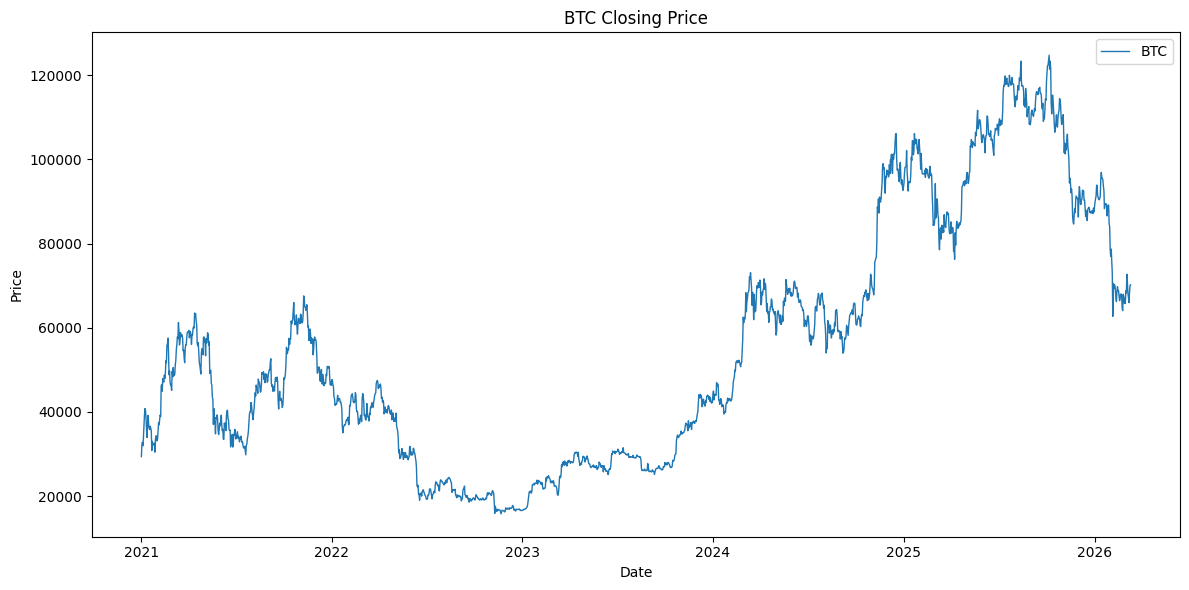

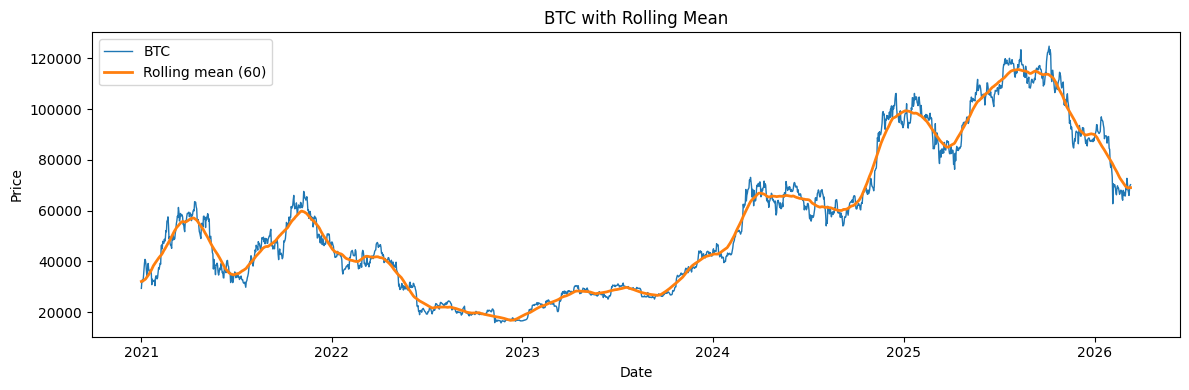

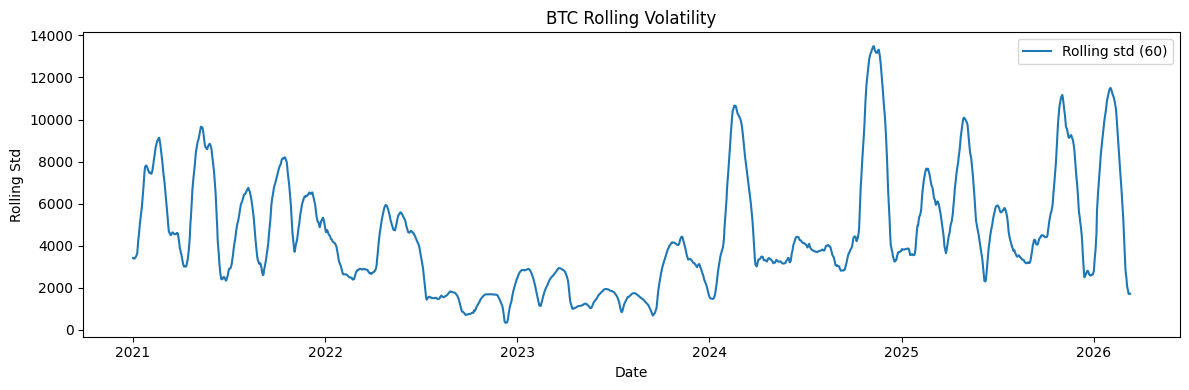

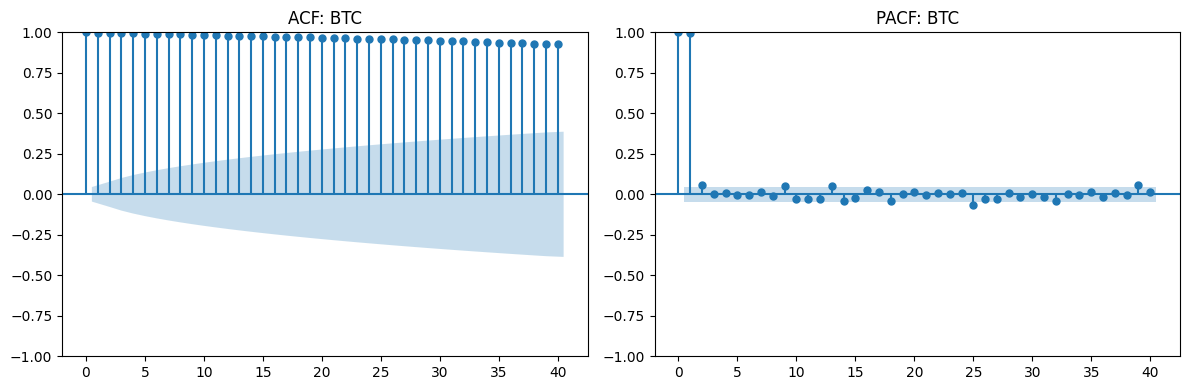

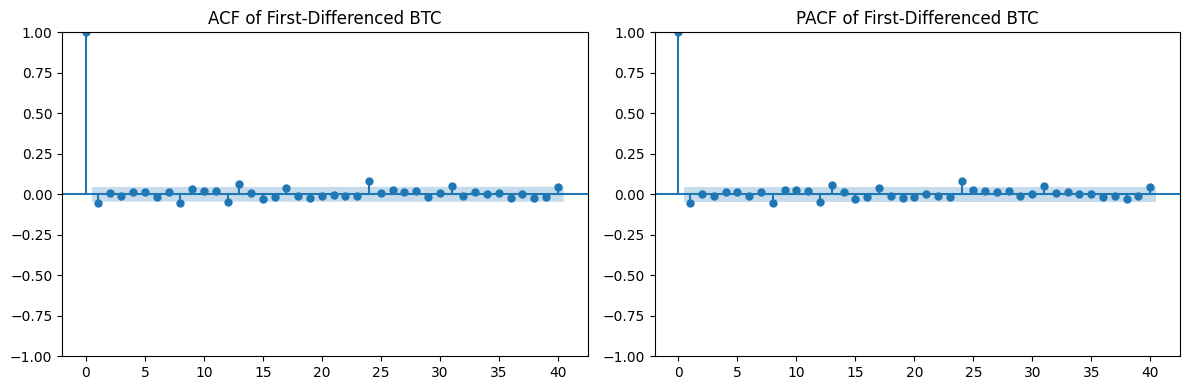

ADF on level:
{'stat': np.float64(-1.4177944113474672), 'pvalue': np.float64(0.5737161517849194)}
ADF on first difference:
{'stat': np.float64(-7.397055400010896), 'pvalue': np.float64(7.728588864654498e-11)}


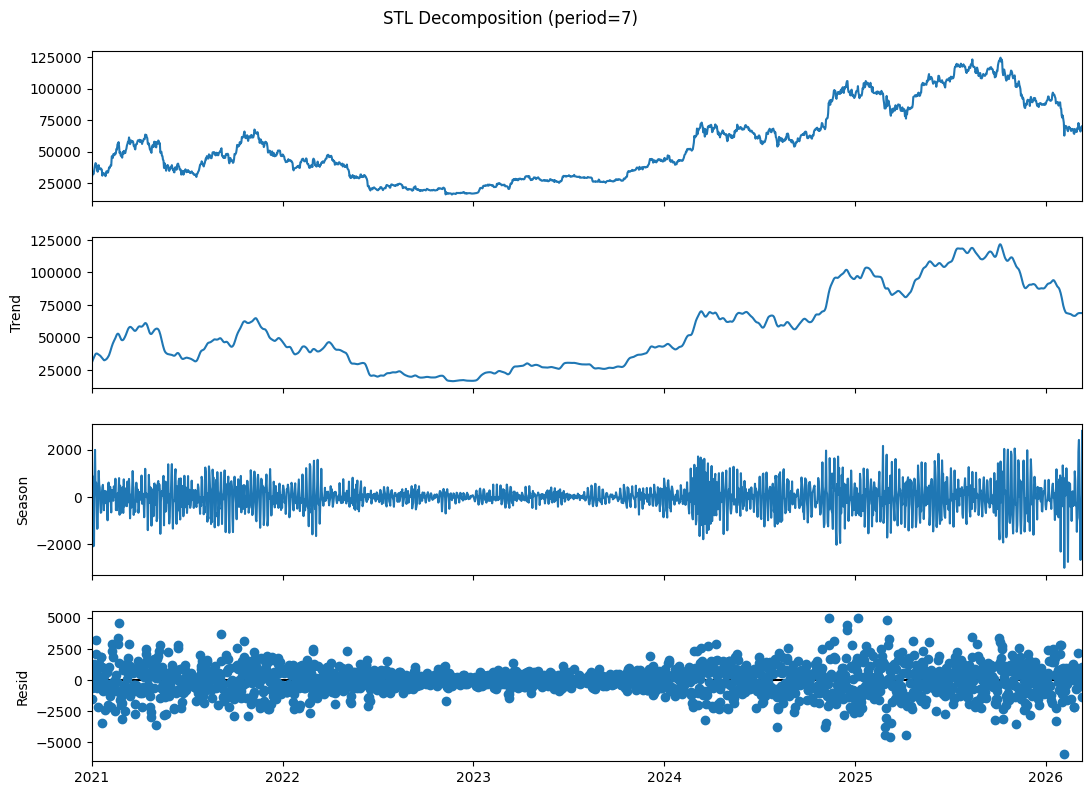

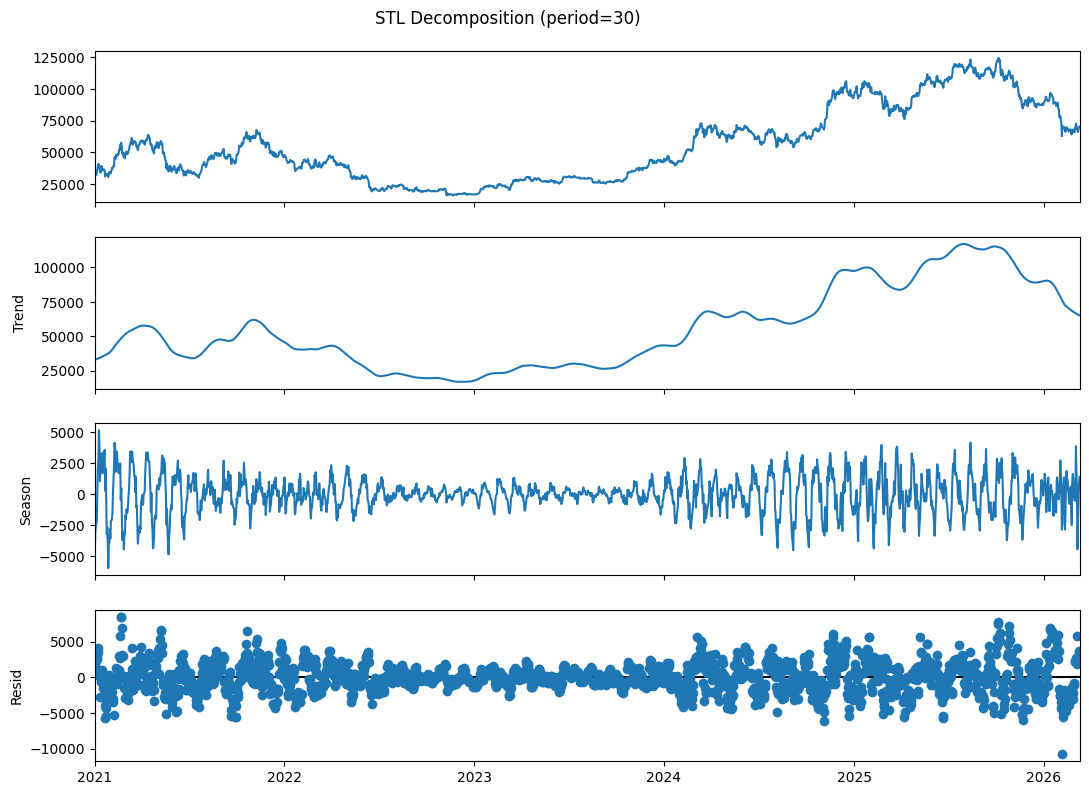

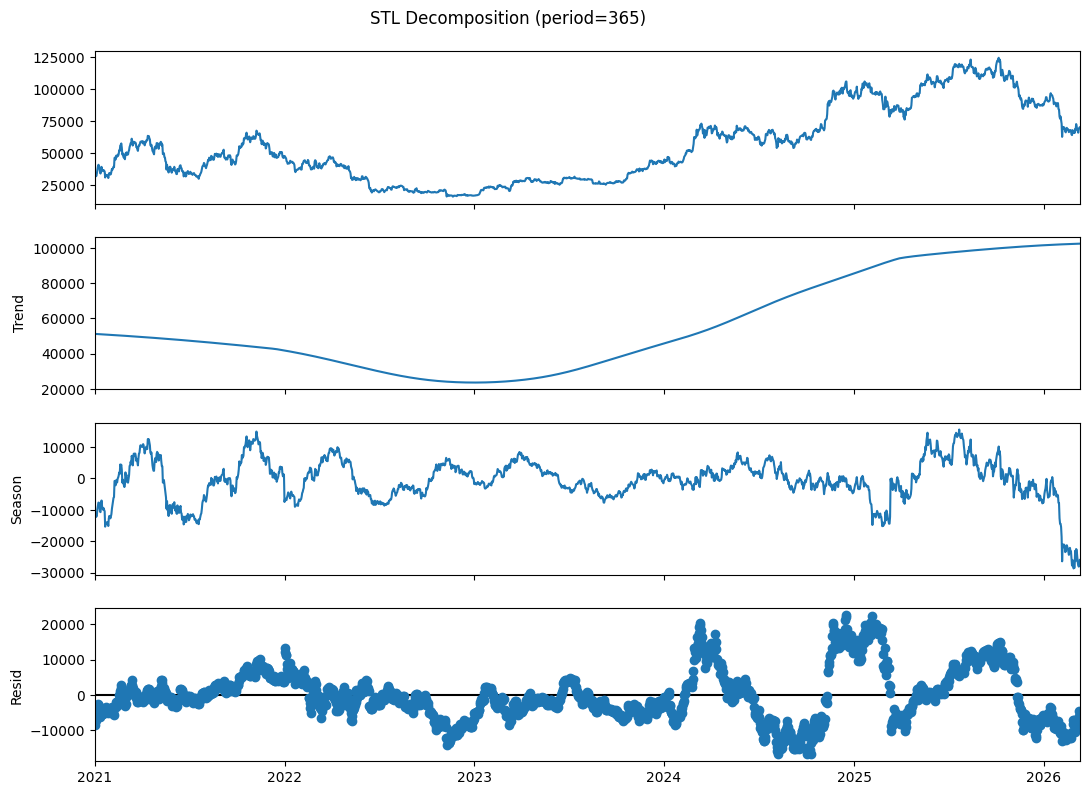

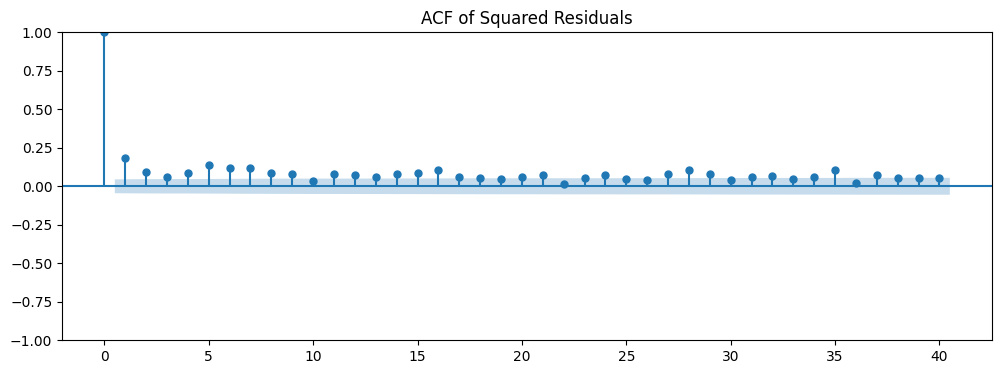


Ljung-Box Test:
      lb_stat  lb_pvalue
10  14.857571   0.137341
20  33.395704   0.030515
40  64.060224   0.009218


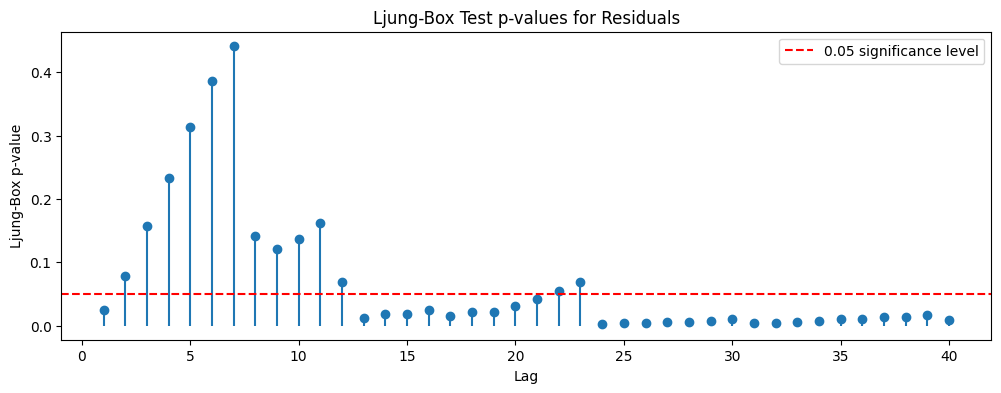

In [8]:
# plt.figure(figsize=(12, 6))
# plt.plot(df_orig, label=DATA_SET, linewidth=1)
# plt.title("BTC Closing Price")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.legend(ncol=3)
# plt.tight_layout()
# plt.show()



plt.figure(figsize=(12, 6))
plt.plot(df, label=DATA_SET, linewidth=1)
plt.title("BTC Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()
window = 60
rmv = rolling_mean_vol(df, window=window)

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["value"], label=DATA_SET, linewidth=1)
plt.plot(rmv.index, rmv["roll_mean"], label=f"Rolling mean ({window})", linewidth=2)
plt.title("BTC with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["roll_std"], label=f"Rolling std ({window})", linewidth=1.5)
plt.title("BTC Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std")
plt.legend()
plt.tight_layout()
plt.show()

# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df, lags=40, ax=axes[0])
plot_pacf(df, lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF: BTC")
axes[1].set_title("PACF: BTC")
plt.tight_layout()
plt.show()

# ACF / PACF of first difference

dseries = df.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(dseries, lags=40, ax=axes[0])
plot_pacf(dseries, lags=40, ax=axes[1], method="ywm")
axes[0].set_title(f"ACF of First-Differenced {DATA_SET}")
axes[1].set_title(f"PACF of First-Differenced {DATA_SET}")
plt.tight_layout()
plt.show()

adf_level = adfuller(df.dropna(), autolag=None)
adf_diff = adfuller(dseries, autolag=None)

print("ADF on level:")
print({"stat": adf_level[0], "pvalue": adf_level[1]})
print("ADF on first difference:")
print({"stat": adf_diff[0], "pvalue": adf_diff[1]})

# STL Decomposition

stl_results = {}
for p in [7, 30, 365]:
    stl = STL(df, period=p)
    res = stl.fit()
    stl_results[p] = {
        "trend": res.trend,
        "seasonal": res.seasonal,
        "resid": res.resid
    }
    fig = res.plot()
    fig.set_size_inches(12,8)
    plt.suptitle(f"STL Decomposition (period={p})", y=1.02)
    plt.show()

# ACF of squared residuals (volatility clustering)

fig, ax = plt.subplots(1,1,figsize=(12,4))
plot_acf(dseries**2, lags=40, ax=ax)
ax.set_title("ACF of Squared Residuals")
plt.show()

# Ljung-Box test for autocorrelation in residuals


lb = acorr_ljungbox(dseries, lags=[10,20,40], return_df=True)
print("\nLjung-Box Test:")
print(lb)


lb_test = acorr_ljungbox(dseries, lags=40, return_df=True)
plt.figure(figsize=(12, 4))
plt.stem(lb_test.index, lb_test['lb_pvalue'], basefmt=" ")
plt.axhline(0.05, color='red', linestyle='--', label='0.05 significance level')
plt.xlabel("Lag")
plt.ylabel("Ljung-Box p-value")
plt.title("Ljung-Box Test p-values for Residuals")
plt.legend()
plt.show()

In [9]:
rows = []

for p, comp in stl_results.items():
    trend = comp["trend"]
    seasonal = comp["seasonal"]
    resid = comp["resid"]

    trend_var = np.var(trend)
    seasonal_var = np.var(seasonal)
    resid_var = np.var(resid)
    total_var = trend_var + seasonal_var + resid_var

    rows.append({
        "period": p,
        "trend_var": trend_var,
        "seasonal_var": seasonal_var,
        "resid_var": resid_var,
        "trend_share": trend_var / total_var,
        "seasonal_share": seasonal_var / total_var,
        "resid_share": resid_var / total_var
    })

decomp_summary = pd.DataFrame(rows)

print("\nSTL Decomposition Summary\n")
decomp_summary.round(4)


STL Decomposition Summary



,period,trend_var,seasonal_var,resid_var,trend_share,seasonal_share,resid_share
0,7,8.568910e+08,3.648322e+05,1.234934e+06,0.9981,0.0004,0.0014
1,30,8.444350e+08,1.954561e+06,4.460062e+06,0.9925,0.0023,0.0052
2,365,7.075470e+08,4.358467e+07,5.290821e+07,0.8800,0.0542,0.0658


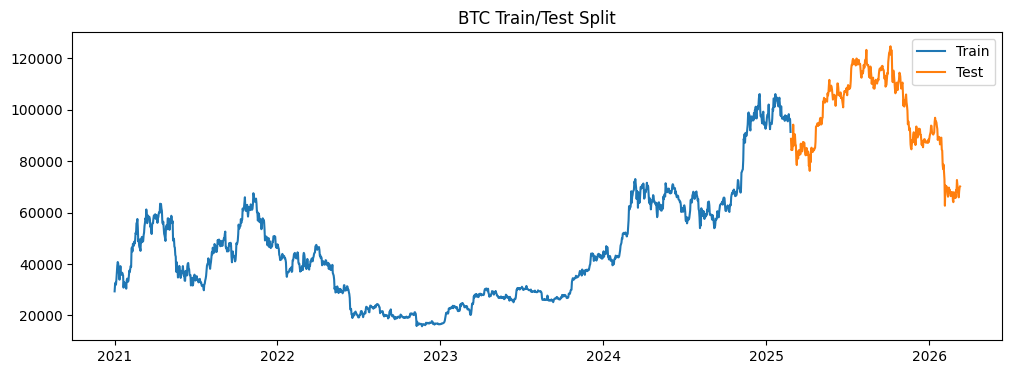

In [10]:
# Train / Test Split

train, test = train_test_split_ts(df, test_size=0.2)

plt.figure(figsize=(12,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title(f"{DATA_SET} Train/Test Split")
plt.legend()
plt.show()



In [11]:
# Complete ARIMA Workflow

def run_arima_pipeline(train, test, p_values=range(0,4), q_values=range(0,4)):
    d_selected, d_table = select_d_by_adf(train, max_d=2)

    results, best_order = arima_grid_search(
        train_series=train,
        p_values=p_values,
        d_values=[d_selected],
        q_values=q_values,
        criterion="aicc"
    )

    fit = fit_arima(train, best_order)
    forecast = forecast_model(fit, train, test)
    residual_diagnostics(fit)

    return fit, forecast

# SARIMA Pipeline

def run_sarima_pipeline(train, test, order=(1,1,1), seasonal_order=(1,0,1,7)):

    print("----- SARIMA MODEL -----")

    sarima_fit = fit_sarima(train, order, seasonal_order)

    forecast = forecast_model(sarima_fit, train, test)

    residual_diagnostics(sarima_fit)

    return sarima_fit, forecast

# Rolling Forecast Evaluation

def rolling_arima_forecast(series, order=(2,1,2), horizon=20, window=200):

    y_true = []
    y_pred = []

    for i in range(window, len(series)-horizon):

        train = series.iloc[:i]
        test = series.iloc[i:i+horizon]

        model = ARIMA(train, order=order).fit()

        forecast = model.forecast(steps=horizon)

        y_true.append(test.values)
        y_pred.append(forecast.values)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return horizonwise_errors(y_true, y_pred)

# Rolling forecast evaluation for SARIMA

def rolling_sarima_forecast(series, order=(1,1,1), seasonal_order=(1,0,1,7), horizon=20, window=200):

    y_true = []
    y_pred = []

    for i in range(window, len(series) - horizon):

        train = series.iloc[:i]
        test = series.iloc[i:i+horizon]

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast = model.forecast(steps=horizon)

        y_true.append(test.values)
        y_pred.append(forecast.values)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return horizonwise_errors(y_true, y_pred)

# ARIMA order selection by AICc

def arima_grid_search(train_series, p_values, d_values, q_values, criterion="aic"):
    rows = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    fit = ARIMA(train_series, order=(p, d, q)).fit()
                    k = fit.params.shape[0]
                    n = len(train_series)
                    aicc = fit.aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf

                    rows.append({
                        "p": p,
                        "d": d,
                        "q": q,
                        "aicc": aicc
                    })
                except Exception:
                    continue

    results = pd.DataFrame(rows)

    if results.empty:
        raise ValueError("No ARIMA models were successfully fit.")

    results = results.sort_values(by=criterion).reset_index(drop=True)
    best_order = tuple(results.loc[0, ["p", "d", "q"]].astype(int))

    return results, best_order

# SARIMA order selection by AICc

def sarima_grid_search(train_series,
                       p_values, d_values, q_values,
                       P_values, D_values, Q_values,
                       seasonal_period,
                       criterion="aicc"):
    rows = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                for P in P_values:
                    for D in D_values:
                        for Q in Q_values:
                            try:
                                fit = SARIMAX(
                                    train_series,
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, seasonal_period),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)
                                k = fit.params.shape[0]
                                n = len(train_series)
                                aicc = fit.aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf

                                rows.append({
                                    "p": p, "d": d, "q": q,
                                    "P": P, "D": D, "Q": Q,
                                    "s": seasonal_period,
                                    "aicc": aicc
                                })
                            except Exception:
                                continue

    results = pd.DataFrame(rows)

    if results.empty:
        raise ValueError("No SARIMA models were successfully fit.")

    results = results.sort_values(by=criterion).reset_index(drop=True)

    best = results.iloc[0]
    best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
    best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), int(best["s"]))

    return results, best_order, best_seasonal

# Evaluate candidate ARIMA models on test data

def evaluate_arima_candidates(train_series, test_series, candidates):
    rows = []

    for order in candidates:
        try:
            fit = ARIMA(train_series, order=order).fit()
            forecast = fit.forecast(steps=len(test_series))

            mae = mean_absolute_error(test_series, forecast)
            pm = np.sum((test_series - forecast) ** 2) / np.sum((test_series - np.mean(test_series)) ** 2)
            bias = np.mean(forecast - test_series)
            mape = np.mean(np.abs((test_series - forecast) / (test_series + 1e-8))) * 100

            rows.append({
                "order": order,
                "aic": fit.aic,
                "bic": fit.bic,
                "mae": mae,
                "pm": pm,
                "mape": mape,
                "bias": bias
            })
        except Exception:
            continue

    results = pd.DataFrame(rows).sort_values("pm").reset_index(drop=True)
    return results

In [12]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.simplefilter("ignore", ConvergenceWarning)

Selected d = 1 based on ADF p-value = 0.0000
   d   adf_stat        pvalue
0  0  -0.539238  8.841294e-01
1  1 -10.268323  4.063545e-18
Top ARIMA candidates:
   p  d  q          aicc
0  3  1  2  26429.820007
1  0  1  0  26444.044567
2  1  1  0  26444.869306
3  0  1  1  26444.908284
4  1  1  1  26446.025997
5  2  1  0  26446.348279
6  0  1  2  26446.433571
7  2  1  1  26447.936035
8  3  1  0  26448.228096
9  0  1  3  26448.385247
Best ARIMA order: (3, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1516
Model:                 ARIMA(3, 1, 2)   Log Likelihood              -13208.882
Date:                Wed, 29 Apr 2026   AIC                          26429.764
Time:                        20:05:54   BIC                          26461.703
Sample:                    01-01-2021   HQIC                         26441.657
                         - 02-24-2025                             

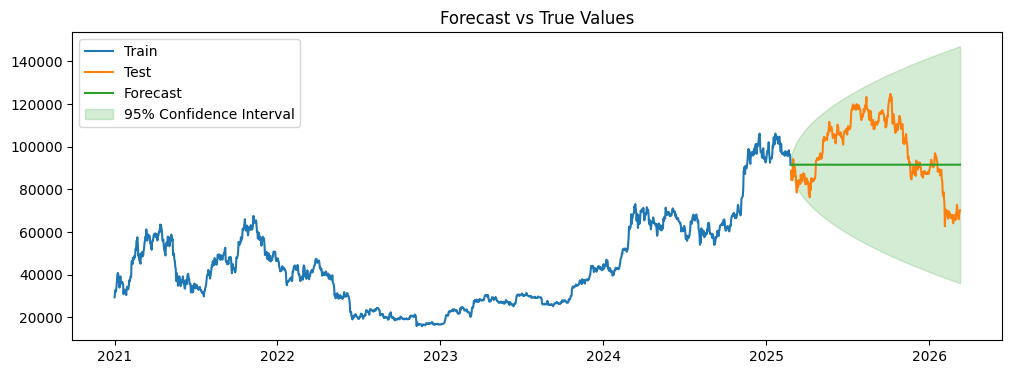

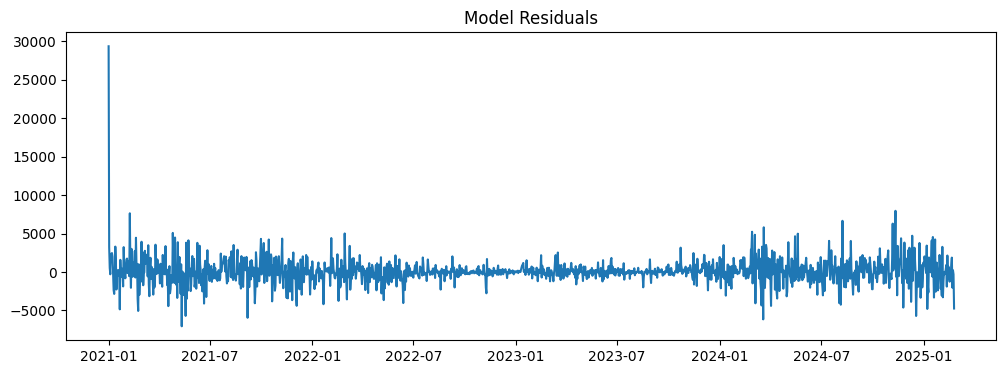

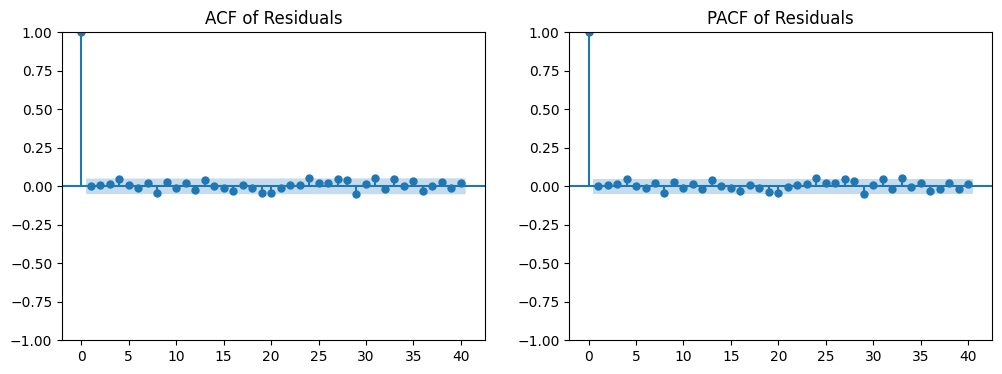


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10   9.358276   0.498473
20  20.476215   0.428517
40  49.488541   0.144525


In [13]:
# ARIMA

d_selected, d_table = select_d_by_adf(train, max_d=3, alpha=0.05)
print(d_table)

arima_results, best_arima_order = arima_grid_search(
    train_series=train,
    p_values=range(0, 4),
    d_values=[d_selected],
    q_values=range(0, 4),
    criterion="aicc"
)

print("Top ARIMA candidates:")
print(arima_results.head(10))
print("Best ARIMA order:", best_arima_order)

arima_fit = fit_arima(train, best_arima_order)
arima_forecast = forecast_model(arima_fit, train, test)
residual_diagnostics(arima_fit)

In [14]:
# Top ARIMA candidates on test set

top_arima_candidates = [
    tuple(arima_results.loc[i, ["p", "d", "q"]].astype(int))
    for i in range(min(5, len(arima_results)))
]

arima_test_compare = evaluate_arima_candidates(train, test, top_arima_candidates)

print("ARIMA candidates ranked by test PM:")
(arima_test_compare)

ARIMA candidates ranked by test PM:


,order,aic,bic,mae,pm,mape,bias
0,"(3, 1, 2)",26429.764341,26461.703365,13997.165038,1.162950,14.288576,-6220.252239
1,"(1, 1, 0)",26444.861375,26455.507716,14002.708880,1.164469,14.290103,-6249.174324
2,"(0, 1, 1)",26444.900353,26455.546695,14002.849618,1.164510,14.290133,-6249.970578
3,"(1, 1, 1)",26446.010124,26461.979636,14011.673321,1.166948,14.292571,-6296.026994
4,"(0, 1, 0)",26444.041925,26449.365096,14026.705557,1.171134,14.296746,-6374.548715


Top SARIMA candidates:
   p  d  q  P  D  Q  s          aicc
0  1  1  2  0  1  1  7  26236.482408
1  1  1  2  1  1  1  7  26237.690997
2  2  1  2  1  1  1  7  26241.305964
3  0  1  2  0  1  1  7  26244.248660
4  0  1  2  1  1  1  7  26246.127558
5  1  1  1  0  1  1  7  26256.632559
6  2  1  1  0  1  1  7  26257.456580
7  1  1  1  1  1  1  7  26258.532333
8  2  1  1  1  1  1  7  26259.447798
9  0  1  1  0  1  1  7  26260.138495
Best SARIMA order: (1, 1, 2)
Best seasonal order: (0, 1, 1, 7)
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1516
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 7)   Log Likelihood              -13113.221
Date:                             Wed, 29 Apr 2026   AIC                          26236.443
Time:                                     20:07:08   BIC                          26263.002
Sample:                                 01-01-2

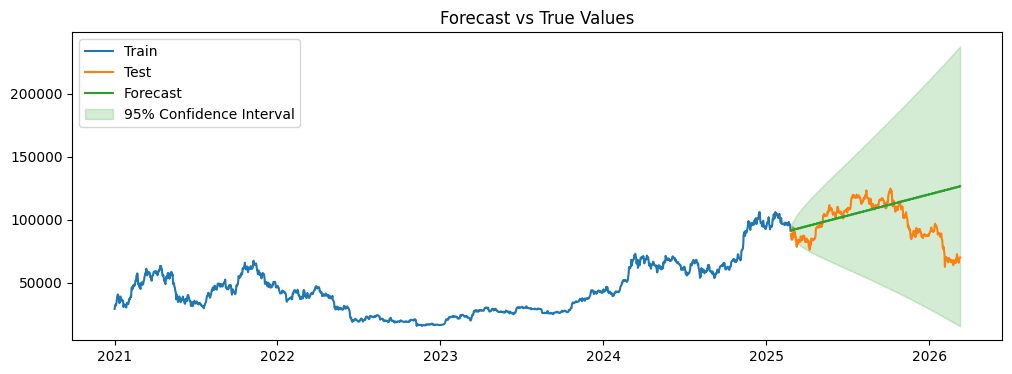

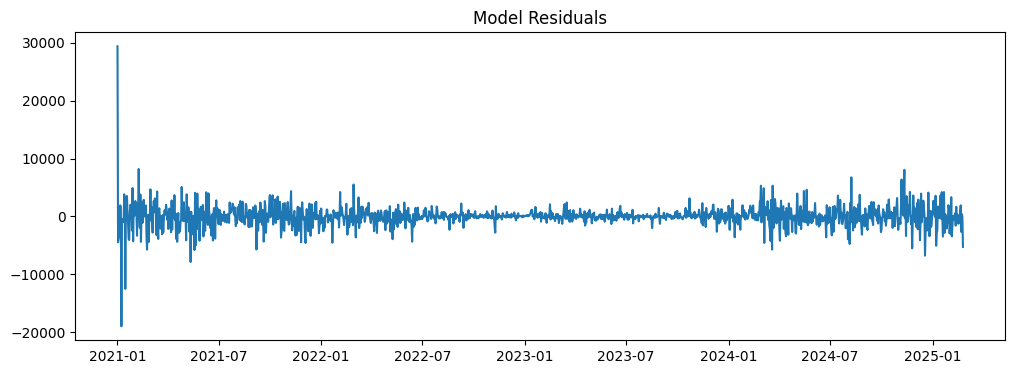

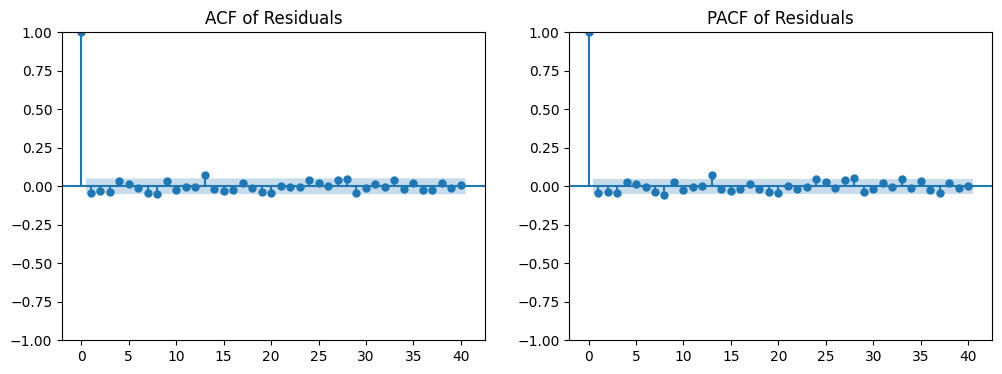


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10  18.336255   0.049550
20  35.875843   0.015906
40  56.792233   0.041187


In [15]:
seasonal_period = 7   # change if needed

sarima_results, best_order, best_seasonal = sarima_grid_search(
    train_series=train,
    p_values=range(0, 3),
    d_values=[d_selected],
    q_values=range(0, 3),
    P_values=range(0, 2),
    D_values=[0, 1],
    Q_values=range(0, 2),
    seasonal_period=seasonal_period,
    criterion="aicc"
)

print("Top SARIMA candidates:")
print(sarima_results.head(10))
print("Best SARIMA order:", best_order)
print("Best seasonal order:", best_seasonal)

sarima_fit = fit_sarima(train, best_order, best_seasonal)
sarima_forecast = forecast_model(sarima_fit, train, test)
residual_diagnostics(sarima_fit)

In [16]:
# Top SARIMA candidates on test set

top_sarima_candidates = [
    (
        tuple(sarima_results.loc[i, ["p", "d", "q"]].astype(int)),
        tuple(sarima_results.loc[i, ["P", "D", "Q", "s"]].astype(int))
    )
    for i in range(min(5, len(sarima_results)))
]

rows = []

for order, seasonal_order in top_sarima_candidates:
    try:
        fit = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast = fit.forecast(steps=len(test))

        mape = np.mean(np.abs((test - forecast) / (test+1e-8))) * 100
        mae = mean_absolute_error(test, forecast)
        bias = np.mean(forecast - test)
        pm = np.sum((test - forecast) ** 2) / np.sum((test - np.mean(test)) ** 2)

        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fit.aic,
            "bic": fit.bic,
            "mae": mae,
            "pm": pm,
            "mape": mape,
            "bias": bias,
        })
    except Exception:
        continue

sarima_test_compare = pd.DataFrame(rows).sort_values("mape").reset_index(drop=True)

print("SARIMA candidates ranked by test MAPE:")
sarima_test_compare

SARIMA candidates ranked by test MAPE:


,order,seasonal_order,aic,bic,mae,pm,mape,bias
0,"(1, 1, 2)","(1, 1, 1, 7)",26237.635331,26269.506648,16662.719412,2.302197,19.939323,11036.505766
1,"(2, 1, 2)","(1, 1, 1, 7)",26241.231694,26278.414897,16677.696200,2.309739,19.963032,11094.477739
2,"(1, 1, 2)","(0, 1, 1, 7)",26236.442672,26263.002103,16729.577549,2.334913,20.045856,11308.202840
3,"(0, 1, 2)","(1, 1, 1, 7)",26246.087822,26272.647253,16753.150963,2.345712,20.079000,11363.603993
4,"(0, 1, 2)","(0, 1, 1, 7)",26244.222187,26265.469732,16763.247088,2.350810,20.096682,11421.036656


    horizon         bias     var_error          mae        pm      mape
0         1    58.423937  5.028698e+06  1593.422169  0.028888  1.650713
1         2   117.173920  9.318829e+06  2253.287077  0.052830  2.315786
2         3   168.593611  1.322190e+07  2777.409080  0.073986  2.864835
3         4   218.778619  1.723623e+07  3133.234865  0.095120  3.240295
4         5   262.299328  2.104791e+07  3494.696565  0.114892  3.618039
5         6   306.853789  2.502884e+07  3863.686938  0.135170  3.991271
6         7   380.310121  2.942683e+07  4207.171584  0.156826  4.351461
7         8   432.366121  3.407340e+07  4487.098408  0.179579  4.654258
8         9   492.555602  3.818566e+07  4821.061196  0.198771  5.009863
9        10   557.016308  4.193481e+07  5095.455228  0.215224  5.314328
10       11   615.425893  4.608554e+07  5319.778253  0.233380  5.566432
11       12   675.718022  5.026977e+07  5550.328609  0.251755  5.837827
12       13   735.423164  5.392494e+07  5685.072866  0.267200  6

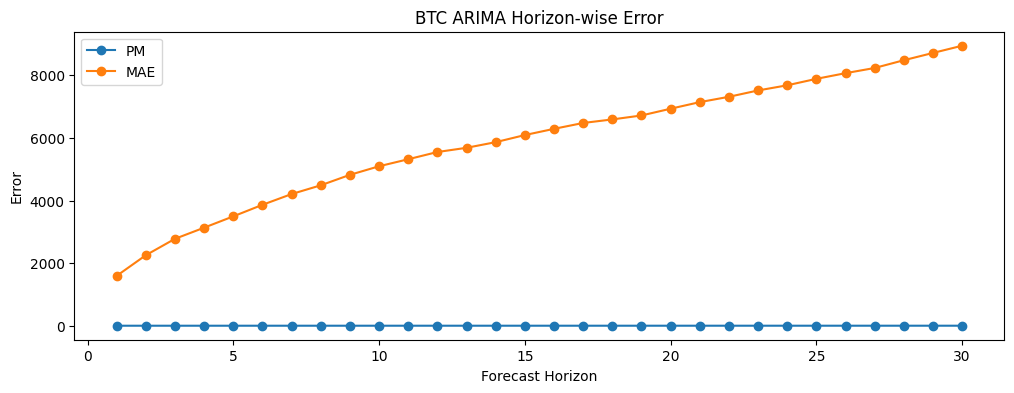

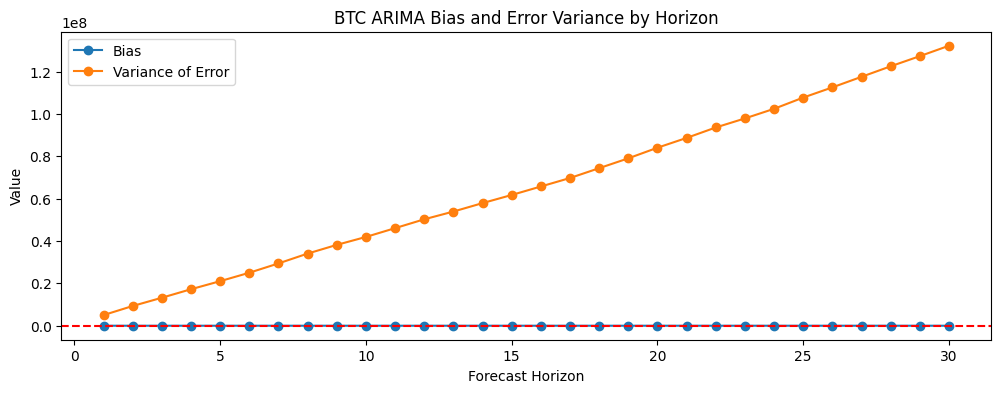

In [17]:
# Rolling forecast evaluation for ARIMA
LONG_H      = 30
ROLLING_WINDOW = len(train)
rolling_arima_results = rolling_arima_forecast(
    series=df,
    order=best_arima_order,
    horizon=LONG_H,
    window=ROLLING_WINDOW
)

print(rolling_arima_results)

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["pm"], marker="o", label="PM")
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["mae"], marker="o", label="MAE")
plt.title(f"{DATA_SET} ARIMA Horizon-wise Error")
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["bias"], marker="o", label="Bias")
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["var_error"], marker="o", label="Variance of Error")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} ARIMA Bias and Error Variance by Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.legend()
plt.show()

    horizon         bias     var_error          mae        pm       mape
0         1   125.496584  5.012987e+06  1604.470376  0.028868   1.665089
1         2   241.507191  9.315748e+06  2277.743490  0.053065   2.344696
2         3   352.187251  1.330471e+07  2806.685323  0.074982   2.897264
3         4   461.550382  1.735752e+07  3171.982318  0.096697   3.281114
4         5   567.351115  2.113184e+07  3537.239404  0.116725   3.661556
5         6   670.929139  2.508511e+07  3924.255278  0.137388   4.053078
6         7   804.816593  2.953499e+07  4250.584208  0.160068   4.399930
7         8   915.452298  3.417679e+07  4529.160099  0.183533   4.701208
8         9  1034.788192  3.832597e+07  4873.110386  0.203780   5.066213
9        10  1164.400010  4.194840e+07  5173.741146  0.220620   5.395346
10       11  1289.334455  4.593977e+07  5413.031089  0.239095   5.663890
11       12  1403.387364  5.006579e+07  5620.267513  0.258251   5.919553
12       13  1514.376220  5.363082e+07  5744.858462

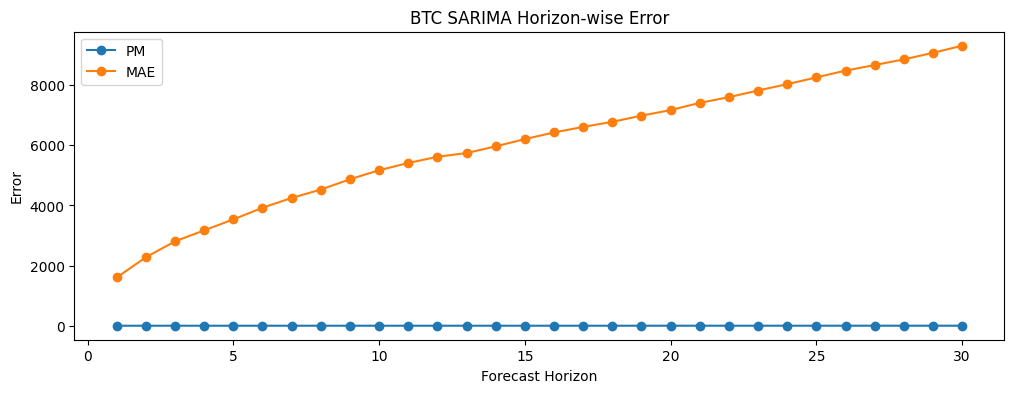

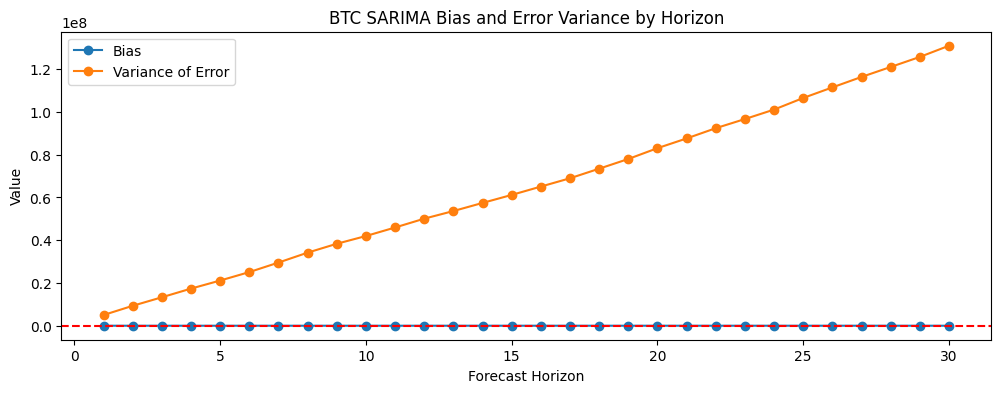

In [18]:
# Rolling forecast evaluation for SARIMA

rolling_sarima_results = rolling_sarima_forecast(
    series=df,
    order=best_order,
    seasonal_order=best_seasonal,
    horizon=LONG_H,
    window=ROLLING_WINDOW
)

print(rolling_sarima_results)

plt.figure(figsize=(12,4))
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["pm"], marker="o", label="PM")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["mae"], marker="o", label="MAE")
plt.title(f"{DATA_SET} SARIMA Horizon-wise Error")
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["bias"], marker="o", label="Bias")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["var_error"], marker="o", label="Variance of Error")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} SARIMA Bias and Error Variance by Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.legend()
plt.show()

In [20]:
os.makedirs("./figures", exist_ok=True)

FIG_DIR = f"./figures_{DATA_SET}"   # one folder per dataset

os.makedirs(FIG_DIR, exist_ok=True)

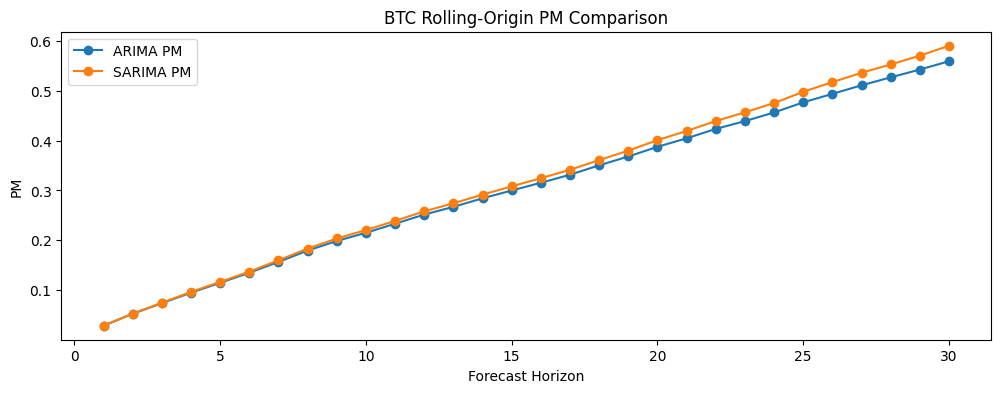

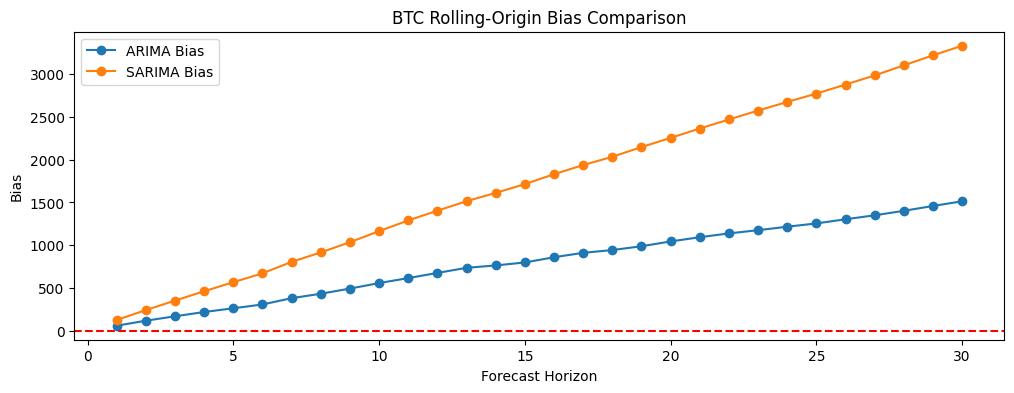

In [22]:
plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["pm"], marker="o", label="ARIMA PM")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["pm"], marker="o", label="SARIMA PM")
plt.title(f"{DATA_SET} Rolling-Origin PM Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("PM")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["bias"], marker="o", label="ARIMA Bias")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["bias"], marker="o", label="SARIMA Bias")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} Rolling-Origin Bias Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("Bias")
plt.legend()
plt.savefig(f"figures/{DATA_SET}_arima_rolling_sarima_results.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# Side-by-side comparison

final_compare = pd.DataFrame([
    accuracy_metrics(test, arima_forecast, label=f"ARIMA {best_arima_order}"),
    accuracy_metrics(test, sarima_forecast, label=f"SARIMA {best_order} x {best_seasonal}")
])

final_compare

ARIMA (3, 1, 2) MAE:   13997.1650
ARIMA (3, 1, 2) MAPE:  14.2886%
ARIMA (3, 1, 2) Bias:  -6220.2522
ARIMA (3, 1, 2) PM:    1.1629

SARIMA (1, 1, 2) x (0, 1, 1, 7) MAE:   16729.5775
SARIMA (1, 1, 2) x (0, 1, 1, 7) MAPE:  20.0459%
SARIMA (1, 1, 2) x (0, 1, 1, 7) Bias:  11308.2028
SARIMA (1, 1, 2) x (0, 1, 1, 7) PM:    2.3349



,Model,MAE,MAPE,Bias,PM
0,"ARIMA (3, 1, 2)",13997.165038,14.288576,-6220.252239,1.162950
1,"SARIMA (1, 1, 2) x (0, 1, 1, 7)",16729.577549,20.045856,11308.202840,2.334913


In [24]:
# NeuralForecast expects columns: unique_id | ds | y

def series_to_nf(name: str, series: pd.Series) -> pd.DataFrame:
    """Convert a pd.Series with DatetimeIndex to NeuralForecast format."""
    out = pd.DataFrame({"ds": series.index, "y": series.values})
    out["unique_id"] = name
    return out[["unique_id", "ds", "y"]].reset_index(drop=True)

HORIZONS    = [7, 14, 30]
MAX_H       = max(HORIZONS)
EVAL_H      = 14
INPUT_SIZE  = 60
MAX_STEPS   = 200
FREQ        = "D"

# colors_used  reused across all plots
colors_used  = {
    "ARIMA"               : "#6c757d",
    "SARIMA"              : "#adb5bd",
    "TCN"                 : "#2196F3",
    "Autoformer"          : "#E91E63",
    "Autoformer_NoDecomp" : "#FF9800",
}

print(f"NF_AVAILABLE = {NF_AVAILABLE}")
print(f"Horizons     = {HORIZONS}")
print(f"Input size   = {INPUT_SIZE}")
print(f"Max steps    = {MAX_STEPS}")



NF_AVAILABLE = True
Horizons     = [7, 14, 30]
Input size   = 60
Max steps    = 200


In [25]:
# trainer_kwargs patcher
_VALID_TRAINER_KWARGS = set(inspect.signature(pl.Trainer.__init__).parameters.keys())

def _clean_trainer_kwargs(model):
    if hasattr(model, "trainer_kwargs"):
        model.trainer_kwargs = {
            k: v for k, v in model.trainer_kwargs.items()
            if k in _VALID_TRAINER_KWARGS
        }
        model.trainer_kwargs["accelerator"] = ACCELERATOR
        model.trainer_kwargs["devices"]     = DEVICES
        # suppress the per-epoch progress bar — speeds up notebook output
        model.trainer_kwargs["enable_progress_bar"] = False
        model.trainer_kwargs["enable_model_summary"] = False
    return model


def make_tcn(h: int) -> TCN:
    m = TCN(
        h             = h,
        input_size    = INPUT_SIZE,
        kernel_size   = 3,
        dilations     = [1, 2, 4, 8],
        dropout       = 0.1,
        loss          = MAE(),
        max_steps     = MAX_STEPS,
        learning_rate = 1e-3,
        alias         = "TCN",
    )
    return _clean_trainer_kwargs(m)

def make_autoformer(h: int) -> Autoformer:
    m = Autoformer(
        h                = h,
        input_size       = INPUT_SIZE,
        hidden_size      = 16,
        n_head           = 2,
        encoder_layers   = 2,
        decoder_layers   = 1,
        MovingAvg_window = 25,
        conv_hidden_size = 16,
        dropout          = 0.1,
        loss             = MAE(),
        max_steps        = MAX_STEPS,
        learning_rate    = 1e-3,
        alias            = "Autoformer",
    )
    return _clean_trainer_kwargs(m)

def make_autoformer_nodecomp(h: int) -> Autoformer:
    m = Autoformer(
        h                = h,
        input_size       = INPUT_SIZE,
        hidden_size      = 16,
        n_head           = 2,
        encoder_layers   = 2,
        decoder_layers   = 1,
        MovingAvg_window = 1,           # ablation: no decomposition
        conv_hidden_size = 16,
        dropout          = 0.1,
        loss             = MAE(),
        max_steps        = MAX_STEPS,
        learning_rate    = 1e-3,
        alias            = "Autoformer_NoDecomp",
    )
    return _clean_trainer_kwargs(m)

_t = make_tcn(7)
bad = set(_t.trainer_kwargs.keys()) - _VALID_TRAINER_KWARGS
print(f"Bad trainer_kwargs keys : {bad}")           # must be set()
print(f"Accelerator set to      : {_t.trainer_kwargs['accelerator']}")
print(f"Progress bar            : {_t.trainer_kwargs['enable_progress_bar']}")

INFO:lightning_fabric.utilities.seed:Seed set to 1


Bad trainer_kwargs keys : set()
Accelerator set to      : gpu
Progress bar            : False


In [26]:
# Silence Lightning + NeuralForecast verbose logging
import logging, os, warnings

os.environ["LIGHTNING_DISABLE_PYTORCH_LIGHTNING_LOGS"] = "1"

for name in [
    "pytorch_lightning",
    "pytorch_lightning.utilities.rank_zero",
    "pytorch_lightning.accelerators.cuda",
    "pytorch_lightning.accelerators.mps",
    "lightning",
    "lightning.pytorch",
    "lightning.pytorch.utilities.rank_zero",
    "lightning_fabric",
    "lightning_utilities",
    "neuralforecast",
]:
    logging.getLogger(name).setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=UserWarning,  module="pytorch_lightning")
warnings.filterwarnings("ignore", category=UserWarning,  module="lightning")
warnings.filterwarnings("ignore", category=FutureWarning, module="pytorch_lightning")

print("Lightning logging silenced.")

Lightning logging silenced.


In [27]:
# Multi-seed rolling-origin CV for DL models

import pickle

SEEDS = [1, 7, 42]


CV_CACHE_PATH = os.path.join(FIG_DIR, f"{DATA_SET}_dl_cv_multiseed.pkl")

# # Load from cache if available — saves hours on Colab restarts
# if os.path.exists(CV_CACHE_PATH):
#     with open(CV_CACHE_PATH, "rb") as f:
#         dl_cv_results_multiseed = pickle.load(f)
#     print(f"Loaded cached multi-seed CV from {CV_CACHE_PATH}")
#     print(f"Horizons: {sorted(dl_cv_results_multiseed.keys())}")
#     for h in sorted(dl_cv_results_multiseed.keys()):
#         print(f"  h={h}: seeds = {sorted(dl_cv_results_multiseed[h].keys())}")
if NF_AVAILABLE:
    # {h: {seed: cv_dataframe}}
    dl_cv_results_multiseed = {h: {} for h in HORIZONS}

    nf_btc = series_to_nf(DATA_SET, df)

    for seed in SEEDS:
        print(f"\n{'='*60}\n  SEED = {seed}\n{'='*60}")
        pl.seed_everything(seed, workers=True)

        for h in HORIZONS:
            n_windows_h = max(3, len(test) // h)
            print(f"\n─── seed={seed}  h={h} ───")

            # Rebuild models inside the seed loop so weights re-init under this seed
            models = [make_tcn(h), make_autoformer(h), make_autoformer_nodecomp(h)]
            nf = NeuralForecast(models=models, freq=FREQ)

            cv = nf.cross_validation(
                df        = nf_btc,
                n_windows = n_windows_h,
                step_size = h,
            )
            dl_cv_results_multiseed[h][seed] = cv

    # Save the results so we don't have to recompute on the next session
    with open(CV_CACHE_PATH, "wb") as f:
        pickle.dump(dl_cv_results_multiseed, f)
    print(f"\nDone. Saved → {CV_CACHE_PATH}")

else:
    print("neuralforecast not installed — skipping DL models.")
    dl_cv_results_multiseed = {}


  SEED = 1

─── seed=1  h=7 ───

─── seed=1  h=14 ───

─── seed=1  h=30 ───

  SEED = 7

─── seed=7  h=7 ───

─── seed=7  h=14 ───

─── seed=7  h=30 ───

  SEED = 42

─── seed=42  h=7 ───

─── seed=42  h=14 ───

─── seed=42  h=30 ───

Done. Saved → ./figures_BTC/BTC_dl_cv_multiseed.pkl


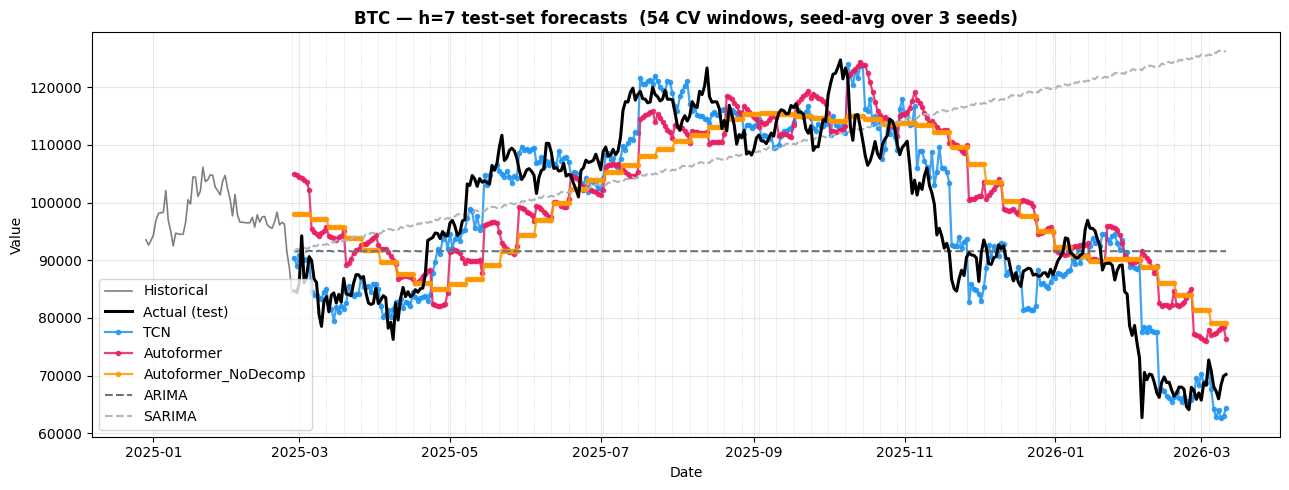

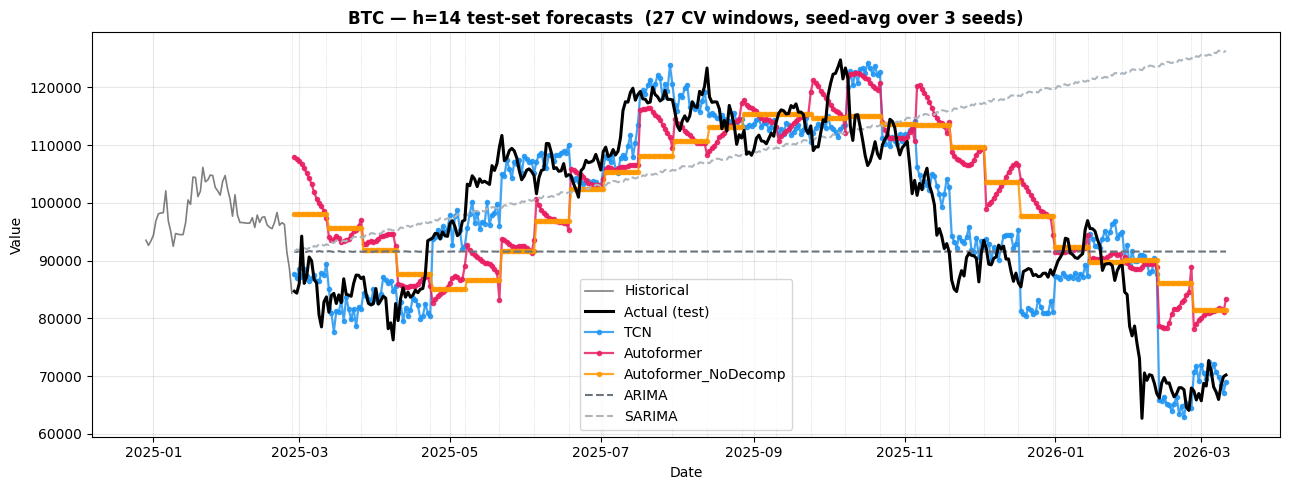

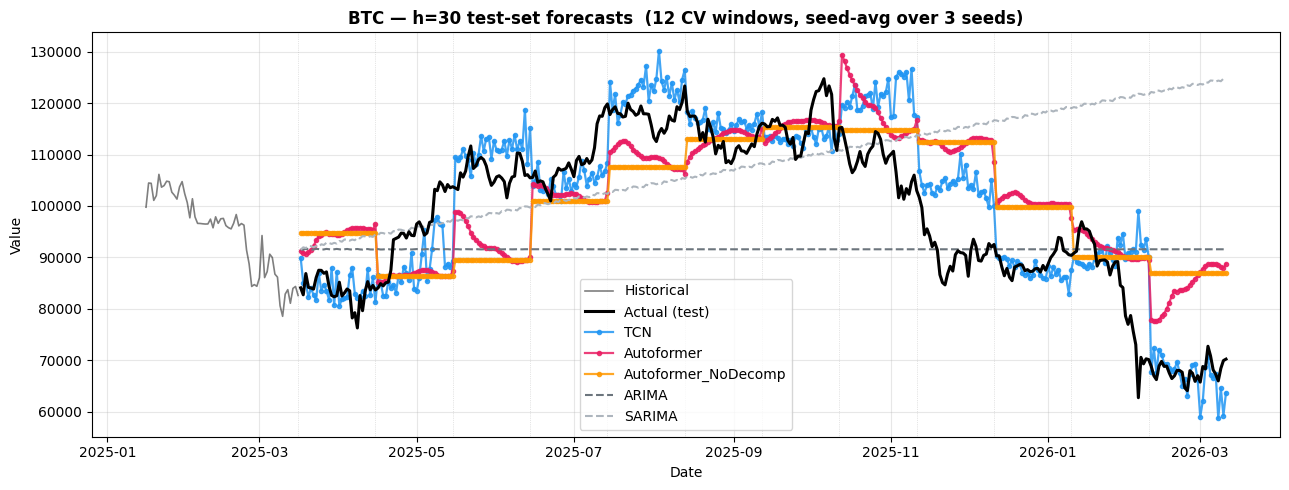

In [28]:
DL_MODELS = ["TCN", "Autoformer", "Autoformer_NoDecomp"]


# Per-horizon test-set plots — all from existing CV results, no retraining

if NF_AVAILABLE and dl_cv_results_multiseed:

    for h in HORIZONS:
        if h not in dl_cv_results_multiseed:
            continue
        seed_dict = dl_cv_results_multiseed[h]
        if not seed_dict:
            continue

        # average DL predictions across seeds at each (cutoff, ds)
        cv_all = pd.concat(seed_dict.values(), ignore_index=True)
        agg = {"y": "first"}
        for m in DL_MODELS:
            if m in cv_all.columns:
                agg[m] = "mean"
        cv_avg = (cv_all.groupby(["cutoff", "ds"], as_index=False)
                        .agg(agg)
                        .sort_values("ds")
                        .reset_index(drop=True))

        # ── ARIMA / SARIMA forecasts on the same dates ──────────────────
        # Refit on train only, then forecast forward to cover cv_avg["ds"]
        n_test_pts = len(cv_avg)

        arima_fit  = ARIMA(train, order=best_arima_order).fit()
        arima_fc   = arima_fit.forecast(steps=n_test_pts)

        sarima_fit = SARIMAX(train, order=best_order,
                             seasonal_order=best_seasonal,
                             enforce_stationarity=False,
                             enforce_invertibility=False).fit(disp=False)
        sarima_fc  = sarima_fit.forecast(steps=n_test_pts)

        # ── plot ─────────────────────────────────────────────────────────
        first_test = cv_avg["ds"].min()
        context_start = first_test - pd.Timedelta(days=60)
        context = df[(df.index >= context_start) & (df.index < first_test)]

        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(context.index, context.values,
                color="black", linewidth=1.2, label="Historical", alpha=0.5)
        ax.plot(cv_avg["ds"], cv_avg["y"],
                color="black", linewidth=2.2, label="Actual (test)", zorder=5)

        # DL forecasts
        for m in DL_MODELS:
            if m in cv_avg.columns:
                ax.plot(cv_avg["ds"], cv_avg[m],
                        marker="o", markersize=3, linewidth=1.6,
                        label=m, color=colors_used.get(m, "gray"), alpha=0.85)

        # classical baselines (one continuous forecast across the test span)
        ax.plot(cv_avg["ds"], arima_fc.values,
                linestyle="--", linewidth=1.5, color="#6c757d", label="ARIMA")
        ax.plot(cv_avg["ds"], sarima_fc.values,
                linestyle="--", linewidth=1.5, color="#adb5bd", label="SARIMA")

        # CV cutoff lines (DL only)
        for cut in cv_avg["cutoff"].unique():
            ax.axvline(cut, color="gray", linestyle=":", linewidth=0.5, alpha=0.4)

        n_windows_used = cv_avg["cutoff"].nunique()
        ax.set_title(f"{DATA_SET} — h={h} test-set forecasts  "
                     f"({n_windows_used} CV windows, seed-avg over {len(seed_dict)} seeds)",
                     fontweight="bold")
        ax.set_xlabel("Date"); ax.set_ylabel("Value")
        ax.legend(loc="best"); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, f"{DATA_SET}_forecast_test_h{h}.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

In [29]:
# Per-seed metrics, then mean ± std aggregation

def cv_metrics(cv_df: pd.DataFrame, model_col: str) -> dict:
    """
    Compute MAE, Bias, PM from a NeuralForecast CV dataframe.
    Compatible with your existing accuracy_metrics() return dict format.
    """
    y_true = cv_df["y"].values
    y_pred = cv_df[model_col].values
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]

    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    bias = np.mean(y_pred - y_true)
    pm   = np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

    return {
        "Model": model_col,
        "MAE" : round(mae,  4),
        "Bias": round(bias, 4),
        "PM"  : round(pm,   4),
    }


long_rows = []

if NF_AVAILABLE and dl_cv_results_multiseed:
    for h, by_seed in dl_cv_results_multiseed.items():
        for seed, cv in by_seed.items():
            for m in DL_MODELS:
                if m in cv.columns:
                    metrics = cv_metrics(cv, m)
                    metrics.update({"h": h, "seed": seed})
                    long_rows.append(metrics)

dl_long = pd.DataFrame(long_rows)
print("Per-seed metrics (long format):")
print(dl_long.to_string(index=False))

# Aggregate to mean / std across seeds
dl_agg = (
    dl_long
    .groupby(["h", "Model"])
    .agg(
        MAE_mean  = ("MAE",  "mean"),
        MAE_std   = ("MAE",  "std"),
        Bias_mean = ("Bias", "mean"),
        Bias_std  = ("Bias", "std"),
        PM_mean   = ("PM",   "mean"),
        PM_std    = ("PM",   "std"),
        n_seeds   = ("MAE",  "count"),
    )
    .round(4)
    .reset_index()
)

print("\nAggregated across seeds (mean ± std):")
print(dl_agg.to_string(index=False))

dl_agg.to_csv(os.path.join(FIG_DIR, f"{DATA_SET}_dl_multiseed_summary.csv"), index=False)

Per-seed metrics (long format):
              Model        MAE      Bias     PM  h  seed
                TCN  3988.7975  291.7004 0.1099  7     1
         Autoformer  8662.6904 3193.3259 0.4450  7     1
Autoformer_NoDecomp  8682.6615 2397.5158 0.4585  7     1
                TCN  3876.7145  458.7666 0.1017  7     7
         Autoformer  8172.7881 2989.7676 0.3987  7     7
Autoformer_NoDecomp  8682.6615 2397.5158 0.4585  7     7
                TCN  3863.1030   92.0088 0.1022  7    42
         Autoformer  8703.6789 3288.7869 0.4581  7    42
Autoformer_NoDecomp  8682.6615 2397.5158 0.4585  7    42
                TCN  4505.7462  869.1978 0.1560 14     1
         Autoformer  9280.2788 3455.5631 0.5195 14     1
Autoformer_NoDecomp  9321.2587 2573.2661 0.5251 14     1
                TCN  4583.6409  777.4029 0.1596 14     7
         Autoformer  9259.2875 3473.8330 0.5179 14     7
Autoformer_NoDecomp  9321.2587 2573.2661 0.5251 14     7
                TCN  4440.8445  103.5011 0.1511 14    42

In [30]:
# Master table with mean ± std for DL models ARIMA / SARIMA stay as point estimates

all_rows = []

for h in HORIZONS:
    # ARIMA / SARIMA no seed variance
    for model_name, errors_df in [("ARIMA", rolling_arima_results ),
                                    ("SARIMA", rolling_sarima_results )]:
        row = errors_df[errors_df["horizon"] == h]
        if not row.empty:
            all_rows.append({
                "Dataset": DATA_SET, "h": h, "Model": model_name,
                "MAE_mean": row["mae"].values[0],   "MAE_std":  np.nan,
                "Bias_mean": row["bias"].values[0], "Bias_std": np.nan,
                "PM_mean":  row["pm"].values[0],    "PM_std":   np.nan,
                "n_seeds":  1,
            })

    # DL — pull from the aggregated frame
    for m in DL_MODELS:
        sub = dl_agg[(dl_agg["h"] == h) & (dl_agg["Model"] == m)]
        if not sub.empty:
            r = sub.iloc[0]
            all_rows.append({
                "Dataset": DATA_SET, "h": h, "Model": m,
                "MAE_mean": r["MAE_mean"], "MAE_std": r["MAE_std"],
                "Bias_mean": r["Bias_mean"], "Bias_std": r["Bias_std"],
                "PM_mean": r["PM_mean"],   "PM_std":  r["PM_std"],
                "n_seeds": int(r["n_seeds"]),
            })

master_table = (
    pd.DataFrame(all_rows)
      .sort_values(["h", "MAE_mean"])
      .reset_index(drop=True)
)

def fmt_pm(mean, std):
    if pd.isna(std):
        return f"{mean:,.1f}"
    return f"{mean:,.1f} ± {std:,.1f}"

master_table["MAE"]  = master_table.apply(lambda r: fmt_pm(r["MAE_mean"],  r["MAE_std"]),  axis=1)
master_table["Bias"] = master_table.apply(lambda r: fmt_pm(r["Bias_mean"], r["Bias_std"]), axis=1)
master_table["PM"]   = master_table.apply(lambda r: fmt_pm(r["PM_mean"],   r["PM_std"]),   axis=1)

print("\n=== MASTER RESULTS TABLE (mean ± std across seeds) ===")
print(master_table[["Dataset", "h", "Model", "MAE", "Bias", "PM", "n_seeds"]].to_string(index=False))

master_table.to_csv(f"./figures/{DATA_SET}_master_results_multiseed.csv", index=False)


=== MASTER RESULTS TABLE (mean ± std across seeds) ===
Dataset  h               Model             MAE            Bias        PM  n_seeds
    BTC  7                 TCN  3,909.5 ± 69.0   280.8 ± 183.6 0.1 ± 0.0        3
    BTC  7               ARIMA         4,207.2           380.3       0.2        1
    BTC  7              SARIMA         4,250.6           804.8       0.2        1
    BTC  7          Autoformer 8,513.1 ± 295.4 3,157.3 ± 152.7 0.4 ± 0.0        3
    BTC  7 Autoformer_NoDecomp   8,682.7 ± 0.0   2,397.5 ± 0.0 0.5 ± 0.0        3
    BTC 14                 TCN  4,510.1 ± 71.5   583.4 ± 418.1 0.2 ± 0.0        3
    BTC 14               ARIMA         5,865.3           763.4       0.3        1
    BTC 14              SARIMA         5,967.4         1,611.4       0.3        1
    BTC 14          Autoformer  9,242.9 ± 47.7 3,368.8 ± 166.3 0.5 ± 0.0        3
    BTC 14 Autoformer_NoDecomp   9,321.3 ± 0.0   2,573.3 ± 0.0 0.5 ± 0.0        3
    BTC 30                 TCN  6,106.0 ± 

Running regime CV: 3 seeds × 20 windows × 3 models
This will take a while — results are cached to CSV after.


─── seed = 1 ───

─── seed = 7 ───

─── seed = 42 ───

Saved → ./figures/BTC_cv_regime.csv

Total CV rows: 840
Unique cutoffs: 20
Seeds: [np.int64(1), np.int64(7), np.int64(42)]

=== Regime assignment ===
regime
High Vol    7
Low Vol     7
Mid Vol     6

Volatility cutoffs: low ≤ 0.0210, high ≥ 0.0238

=== MAE by Volatility Regime (mean ± std across windows × seeds) ===
                              MAE_mean  MAE_std   n
regime   Model                                     
Low Vol  TCN                   7037.62  4857.12  21
         Autoformer            9040.85  7667.25  21
         Autoformer_NoDecomp   8126.41  7373.76  21
Mid Vol  TCN                   6361.14  3289.01  18
         Autoformer           13397.30  5975.58  18
         Autoformer_NoDecomp  11413.02  7083.24  18
High Vol TCN                   3184.98  1402.72  21
         Autoformer           14437.65  2073.36 

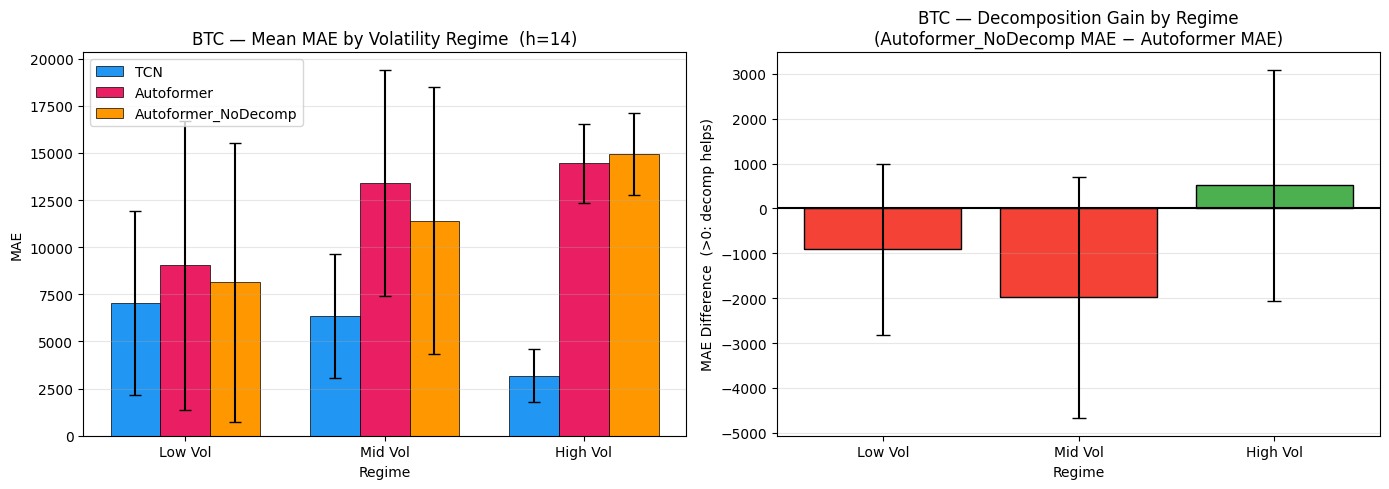


Saved → ./figures/BTC_regime_analysis.png
Saved → ./figures/BTC_regime_mae.csv


In [31]:
REGIME_NWINDOWS  = 20
REGIME_STEP      = 7                # advance one week between windows

CACHE_PATH = f"./figures/{DATA_SET}_cv_regime.csv"

# Build (or load) the dense multi-seed rolling-origin CV
if NF_AVAILABLE and not os.path.exists(CACHE_PATH):
    print(f"Running regime CV: {len(SEEDS)} seeds × {REGIME_NWINDOWS} windows × 3 models")
    print("This will take a while — results are cached to CSV after.\n")

    nf_btc_regime = series_to_nf(DATA_SET, df)
    cv_regime_list = []

    for seed in SEEDS:
        print(f"\n─── seed = {seed} ───")
        pl.seed_everything(seed, workers=True)

        models = [make_tcn(EVAL_H),
                  make_autoformer(EVAL_H),
                  make_autoformer_nodecomp(EVAL_H)]
        nf = NeuralForecast(models=models, freq=FREQ)

        cv_s = nf.cross_validation(
            df        = nf_btc_regime,
            n_windows = REGIME_NWINDOWS,
            step_size = REGIME_STEP,
        )
        cv_s["seed"] = seed
        cv_regime_list.append(cv_s)

    cv_regime = pd.concat(cv_regime_list, ignore_index=True)
    cv_regime.to_csv(CACHE_PATH, index=False)
    print(f"\nSaved → {CACHE_PATH}")
elif os.path.exists(CACHE_PATH):
    print(f"Loading cached regime CV from {CACHE_PATH}")
    cv_regime = pd.read_csv(CACHE_PATH, parse_dates=["ds", "cutoff"])
else:
    raise RuntimeError("NeuralForecast unavailable and no cached file found.")

print(f"\nTotal CV rows: {len(cv_regime)}")
print(f"Unique cutoffs: {cv_regime['cutoff'].nunique()}")
print(f"Seeds: {sorted(cv_regime['seed'].unique())}")

# 30-day volatility of log returns
log_ret      = np.log(df).diff().dropna()
realized_vol = log_ret.rolling(window=30).std().dropna()

cutoffs       = pd.to_datetime(cv_regime["cutoff"]).unique()
window_labels = []

for cut in cutoffs:
    vol_before = realized_vol.loc[realized_vol.index <= cut]
    if len(vol_before) == 0:
        continue
    window_labels.append({"cutoff": cut, "vol": vol_before.iloc[-1]})

vol_df = pd.DataFrame(window_labels)

q33, q67 = vol_df["vol"].quantile([0.33, 0.67]).values
def regime_of(v):
    if v <= q33: return "Low Vol"
    if v >= q67: return "High Vol"
    return "Mid Vol"
vol_df["regime"] = vol_df["vol"].apply(regime_of)

print("\n=== Regime assignment ===")
print(vol_df.groupby("regime").size().to_string())
print(f"\nVolatility cutoffs: low ≤ {q33:.4f}, high ≥ {q67:.4f}")

cv_regime["cutoff"] = pd.to_datetime(cv_regime["cutoff"])
vol_df["cutoff"]    = pd.to_datetime(vol_df["cutoff"])

per_window = []
for (cut, seed), win in cv_regime.groupby(["cutoff", "seed"]):
    regime_match = vol_df.loc[vol_df["cutoff"] == cut, "regime"]
    if regime_match.empty:
        continue
    regime = regime_match.iloc[0]
    for model in DL_MODELS:
        if model in win.columns:
            mae = (win[model] - win["y"]).abs().mean()
            if pd.notna(mae):
                per_window.append({
                    "cutoff": cut, "seed": seed, "regime": regime,
                    "Model" : model, "MAE": mae,
                })

per_window_df = pd.DataFrame(per_window)

regime_table = per_window_df.groupby(["regime", "Model"]).agg(
    MAE_mean = ("MAE", "mean"),
    MAE_std  = ("MAE", "std"),
    n        = ("MAE", "size"),
).round(2)

regime_table = regime_table.reindex(
    pd.MultiIndex.from_product(
        [["Low Vol", "Mid Vol", "High Vol"], DL_MODELS],
        names=["regime", "Model"]
    )
).dropna(how="all")

print("\n=== MAE by Volatility Regime (mean ± std across windows × seeds) ===")
print(regime_table.to_string())

pivot = per_window_df.pivot_table(
    index   = ["cutoff", "seed", "regime"],
    columns = "Model",
    values  = "MAE",
).reset_index()

if "Autoformer" in pivot.columns and "Autoformer_NoDecomp" in pivot.columns:
    pivot["decomp_gain"] = pivot["Autoformer_NoDecomp"] - pivot["Autoformer"]

    gain_summary = pivot.groupby("regime")["decomp_gain"].agg(
        ["mean", "std", "count"]
    ).round(2).reindex(["Low Vol", "Mid Vol", "High Vol"])

    print("\n=== Decomposition gain (Autoformer_NoDecomp − Autoformer) ===")
    print("Positive = decomposition HELPS  |  Negative = decomposition HURTS")
    print(gain_summary.to_string())

    from scipy.stats import ttest_1samp
    print("\n=== One-sample t-test on decomposition gain (H0: mean gain = 0) ===")
    for reg in ["Low Vol", "Mid Vol", "High Vol"]:
        gains = pivot.loc[pivot["regime"] == reg, "decomp_gain"].dropna()
        if len(gains) >= 3:
            t, p = ttest_1samp(gains, 0)
            sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"
            print(f"  {reg:9s}: t = {t:+6.2f}, p = {p:.4f}  ({sig}, n = {len(gains)})")

regime_table.to_csv(f"./figures/{DATA_SET}_regime_mae.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = per_window_df.groupby(["regime", "Model"])["MAE"].agg(["mean", "std"])
plot_data = plot_data.reset_index()

regimes_ord  = ["Low Vol", "Mid Vol", "High Vol"]
models_ord   = DL_MODELS
x            = np.arange(len(regimes_ord))
width        = 0.25

for i, model in enumerate(models_ord):
    sub = plot_data[plot_data["Model"] == model].set_index("regime").reindex(regimes_ord)
    axes[0].bar(x + (i - 1) * width, sub["mean"].values,
                width, yerr=sub["std"].values, capsize=4,
                label=model, color=colors_used.get(model, "gray"),
                edgecolor="black", linewidth=0.5)

axes[0].set_xticks(x)
axes[0].set_xticklabels(regimes_ord)
axes[0].set_title(f"{DATA_SET} — Mean MAE by Volatility Regime  (h={EVAL_H})")
axes[0].set_ylabel("MAE"); axes[0].set_xlabel("Regime")
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].legend()

if "decomp_gain" in pivot.columns:
    gain_means = pivot.groupby("regime")["decomp_gain"].mean().reindex(regimes_ord)
    gain_stds  = pivot.groupby("regime")["decomp_gain"].std().reindex(regimes_ord)
    colors     = ["#4caf50" if g > 0 else "#f44336" for g in gain_means.values]

    axes[1].bar(regimes_ord, gain_means.values,
                yerr=gain_stds.values, capsize=5,
                color=colors, edgecolor="black")
    axes[1].axhline(0, color="black")
    axes[1].set_title(f"{DATA_SET} — Decomposition Gain by Regime\n"
                      "(Autoformer_NoDecomp MAE − Autoformer MAE)")
    axes[1].set_ylabel("MAE Difference  (>0: decomp helps)")
    axes[1].set_xlabel("Regime")
    axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_regime_analysis.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"\nSaved → ./figures/{DATA_SET}_regime_analysis.png")
print(f"Saved → ./figures/{DATA_SET}_regime_mae.csv")

  TCN                   : 840 paired observations
  Autoformer            : 840 paired observations
  Autoformer_NoDecomp   : 840 paired observations

  DIEBOLD-MARIANO PAIRWISE COMPARISONS  —  BTC  (h = 14)
  Sign convention: positive 'Mean |e_A| − |e_B|' means A has larger error.
  ***: p<0.01   **: p<0.05   *: p<0.10   ns: not significant
------------------------------------------------------------------------------------------
            Model A    Model B  Mean |e_A| − |e_B|  DM stat  DM (HLN)  p-value Sig              Winner   n
Autoformer_NoDecomp Autoformer             -732.61   -1.880    -1.850   0.0643   * Autoformer_NoDecomp 840
         Autoformer        TCN             6750.41    7.705     7.581   0.0000 ***                 TCN 840
Autoformer_NoDecomp        TCN             6017.80    5.874     5.780   0.0000 ***                 TCN 840

Saved → ./figures/BTC_diebold_mariano.csv


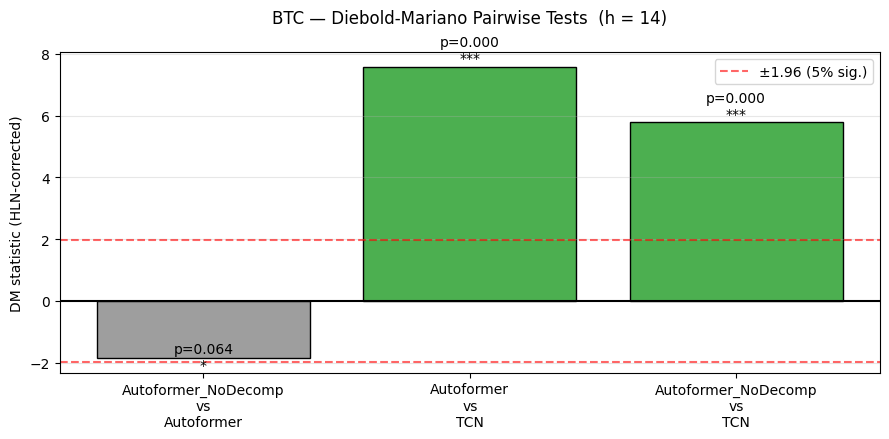

Saved → ./figures/BTC_diebold_mariano.png


In [32]:
from scipy.stats import norm

def diebold_mariano(y_true, y_pred_a, y_pred_b, h=1, loss="abs"):

    y_true   = np.asarray(y_true,  dtype=float)
    y_pred_a = np.asarray(y_pred_a, dtype=float)
    y_pred_b = np.asarray(y_pred_b, dtype=float)

    if loss == "abs":
        e_a = np.abs(y_pred_a - y_true)
        e_b = np.abs(y_pred_b - y_true)
    elif loss == "sq":
        e_a = (y_pred_a - y_true) ** 2
        e_b = (y_pred_b - y_true) ** 2
    else:
        raise ValueError("loss must be 'abs' or 'sq'")

    d = e_a - e_b                # loss differential
    d = d[~np.isnan(d)]
    T = len(d)
    if T < 8:
        return {"DM": np.nan, "DM_HLN": np.nan, "pvalue": np.nan,
                "mean_diff": np.nan, "n": T}

    d_mean = d.mean()

    # Newey-West long-run variance with bandwidth = h-1
    gamma_0 = np.var(d, ddof=0)
    var_d   = gamma_0
    for k in range(1, h):
        gamma_k = np.mean((d[k:] - d_mean) * (d[:-k] - d_mean))
        var_d  += 2 * gamma_k
    var_d = max(var_d, 1e-12)    # guard against negative due to small T

    DM = d_mean / np.sqrt(var_d / T)

    # Harvey-Leybourne-Newbold small-sample correction
    hln_factor = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM_HLN     = DM * hln_factor

    p_value = 2 * (1 - norm.cdf(abs(DM_HLN)))

    return {"DM": DM, "DM_HLN": DM_HLN, "pvalue": p_value,
            "mean_diff": d_mean, "n": T}


cv_regime["cutoff"] = pd.to_datetime(cv_regime["cutoff"])

errors_per_step = {}
for model in DL_MODELS:
    if model in cv_regime.columns:
        df_m = cv_regime[["y", model]].dropna()
        errors_per_step[model] = {
            "y_true": df_m["y"].values,
            "y_pred": df_m[model].values,
        }

# Sanity check
for m, d in errors_per_step.items():
    print(f"  {m:22s}: {len(d['y_true'])} paired observations")

COMPARISONS = [
    ("Autoformer_NoDecomp", "Autoformer"),   # tests whether decomposition helps
    ("Autoformer",          "TCN"),          # tests whether TCN beats Autoformer
    ("Autoformer_NoDecomp", "TCN"),          # full no-decomp vs TCN
]

dm_rows = []
for model_a, model_b in COMPARISONS:
    if model_a not in errors_per_step or model_b not in errors_per_step:
        continue
    res = diebold_mariano(
        y_true   = errors_per_step[model_a]["y_true"],
        y_pred_a = errors_per_step[model_a]["y_pred"],
        y_pred_b = errors_per_step[model_b]["y_pred"],
        h        = EVAL_H,
        loss     = "abs",
    )

    if res["mean_diff"] > 0:
        winner = model_b
        interp = f"{model_b} more accurate"
    else:
        winner = model_a
        interp = f"{model_a} more accurate"

    sig = ("***" if res["pvalue"] < 0.01 else
           "**"  if res["pvalue"] < 0.05 else
           "*"   if res["pvalue"] < 0.10 else "ns")

    dm_rows.append({
        "Model A"      : model_a,
        "Model B"      : model_b,
        "Mean |e_A| − |e_B|": round(res["mean_diff"], 2),
        "DM stat"      : round(res["DM"], 3),
        "DM (HLN)"     : round(res["DM_HLN"], 3),
        "p-value"      : round(res["pvalue"], 4),
        "Sig"          : sig,
        "Winner"       : winner,
        "n"            : res["n"],
    })

dm_table = pd.DataFrame(dm_rows)

print("\n" + "="*90)
print(f"  DIEBOLD-MARIANO PAIRWISE COMPARISONS  —  {DATA_SET}  (h = {EVAL_H})")
print("="*90)
print("  Sign convention: positive 'Mean |e_A| − |e_B|' means A has larger error.")
print("  ***: p<0.01   **: p<0.05   *: p<0.10   ns: not significant")
print("-"*90)
print(dm_table.to_string(index=False))
print("="*90)

dm_table.to_csv(f"./figures/{DATA_SET}_diebold_mariano.csv", index=False)
print(f"\nSaved → ./figures/{DATA_SET}_diebold_mariano.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
labels = [f"{r['Model A']}\nvs\n{r['Model B']}" for _, r in dm_table.iterrows()]
dm_vals = dm_table["DM (HLN)"].values
colors = ["#4caf50" if abs(d) >= 1.96 else "#9e9e9e" for d in dm_vals]

bars = ax.bar(labels, dm_vals, color=colors, edgecolor="black")

# Significance threshold lines
ax.axhline( 1.96, color="red", linestyle="--", alpha=0.6, label="±1.96 (5% sig.)")
ax.axhline(-1.96, color="red", linestyle="--",  alpha=0.6)
ax.axhline(0, color="black")

# Annotate each bar with its p-value
for bar, p, sig in zip(bars, dm_table["p-value"], dm_table["Sig"]):
    height = bar.get_height()
    y_off  = 0.15 if height >= 0 else -0.35
    ax.text(bar.get_x() + bar.get_width()/2, height + y_off,
            f"p={p:.3f}\n{sig}", ha="center")

ax.set_ylabel("DM statistic (HLN-corrected)")
ax.set_title(f"{DATA_SET} — Diebold-Mariano Pairwise Tests  (h = {EVAL_H})\n")
            #  "Negative DM ⇒ Model A more accurate; Positive DM ⇒ Model B more accurate")
ax.legend(loc="best")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_diebold_mariano.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → ./figures/{DATA_SET}_diebold_mariano.png")

In [33]:
RET_NWINDOWS = 10
RET_STEP     = 7
RET_SEED     = 42

# 1) Build log-return series
ret_series = np.log(df).diff().dropna()
print(f"Log-returns: n = {len(ret_series)}, "
      f"mean = {ret_series.mean():.5f}, std = {ret_series.std():.5f}")

# 2) Fit and CV the three DL models on returns
if NF_AVAILABLE:
    nf_ret = series_to_nf(f"{DATA_SET}_ret", ret_series)

    pl.seed_everything(RET_SEED, workers=True)
    models = [make_tcn(EVAL_H),
              make_autoformer(EVAL_H),
              make_autoformer_nodecomp(EVAL_H)]
    nf = NeuralForecast(models=models, freq=FREQ)

    cv_ret = nf.cross_validation(
        df        = nf_ret,
        n_windows = RET_NWINDOWS,
        step_size = RET_STEP,
    )

    # 3) Per-model metrics on the returns scale
    rows = []
    for model in DL_MODELS:
        if model in cv_ret.columns:
            y_t = cv_ret["y"].values
            y_p = cv_ret[model].values
            mask = ~(np.isnan(y_t) | np.isnan(y_p))
            err = y_p[mask] - y_t[mask]
            rows.append({
                "Model": model,
                "MAE_returns" : np.mean(np.abs(err)),
                "RMSE_returns": np.sqrt(np.mean(err**2)),
                "Bias_returns": np.mean(err),
                "n"           : mask.sum(),
            })

    returns_table = pd.DataFrame(rows)
    print("\n=== Forecast accuracy on LOG-RETURNS ===")
    print(returns_table.round(6).to_string(index=False))

    if "Autoformer" in cv_ret.columns and "Autoformer_NoDecomp" in cv_ret.columns:
        mae_decomp   = returns_table.loc[returns_table["Model"] == "Autoformer",
                                          "MAE_returns"].values[0]
        mae_nodecomp = returns_table.loc[returns_table["Model"] == "Autoformer_NoDecomp",
                                          "MAE_returns"].values[0]
        gain_returns = mae_nodecomp - mae_decomp
        gain_pct     = 100 * gain_returns / mae_nodecomp

        print("\n=== Decomposition gain on returns ===")
        print(f"  Autoformer          MAE: {mae_decomp:.6f}")
        print(f"  Autoformer_NoDecomp MAE: {mae_nodecomp:.6f}")
        print(f"  Gain (NoDecomp − Decomp): {gain_returns:+.6f}  ({gain_pct:+.2f}%)")

    returns_table.to_csv(f"./figures/{DATA_SET}_returns_robustness.csv", index=False)
    print(f"\nSaved → ./figures/{DATA_SET}_returns_robustness.csv")

else:
    print("NeuralForecast unavailable — skipping returns robustness.")

Log-returns: n = 1895, mean = 0.00046, std = 0.03069

=== Forecast accuracy on LOG-RETURNS ===
              Model  MAE_returns  RMSE_returns  Bias_returns   n
                TCN     0.024683      0.036303      0.002415 140
         Autoformer     0.023196      0.034821      0.000369 140
Autoformer_NoDecomp     0.021486      0.033552      0.001835 140

=== Decomposition gain on returns ===
  Autoformer          MAE: 0.023196
  Autoformer_NoDecomp MAE: 0.021486
  Gain (NoDecomp − Decomp): -0.001709  (-7.96%)

Saved → ./figures/BTC_returns_robustness.csv


In [34]:
print("="*72)
print(f"  HYPOTHESIS TEST  —  {DATA_SET}")
print("="*72)

# 1) Predictor: STL seasonal variance share (from Cell 7)
print("\n[A] STRUCTURAL CHARACTERISTICS  (predictor)")
print("-"*72)
print(decomp_summary[["period", "trend_share", "seasonal_share", "resid_share"]]
      .round(4).to_string(index=False))
seasonal_share_max = decomp_summary["seasonal_share"].max()
print(f"\n  Max seasonal share across all periods tested: {seasonal_share_max:.4f}")

# 2) Prediction from the proposal's hypothesis
print("\n[B] PROPOSAL'S PREDICTION")
print("-"*72)
if   seasonal_share_max < 0.05:
    expected = "decomposition should provide LITTLE OR NO benefit (weak periodicity)"
    pred_sign = "≈ 0"
elif seasonal_share_max < 0.20:
    expected = "decomposition should provide MODEST benefit"
    pred_sign = "small positive"
else:
    expected = "decomposition should provide CLEAR benefit (strong seasonality)"
    pred_sign = "clearly positive"
print(f"  Seasonal share = {seasonal_share_max:.2%}")
print(f"  Hypothesis predicts: {expected}")
print(f"  Predicted sign of (NoDecomp MAE − Decomp MAE): {pred_sign}")

# 3) Observed: decomposition gain from regime analysis (Cell 9c)
print("\n[C] OBSERVED DECOMPOSITION GAIN  (from regime CV)")
print("-"*72)
overall_gain      = pivot["decomp_gain"].mean()
overall_gain_std  = pivot["decomp_gain"].std()
overall_gain_pct  = 100 * overall_gain / pivot["Autoformer_NoDecomp"].mean()

print(f"  Overall mean gain (NoDecomp − Decomp): {overall_gain:+.2f} ± {overall_gain_std:.2f}")
print(f"  As % of NoDecomp baseline: {overall_gain_pct:+.2f}%")
print("\n  By regime:")
print(gain_summary.to_string())

# 4) Statistical significance from DM test (Cell 9d)
print("\n[D] STATISTICAL SIGNIFICANCE  (Diebold-Mariano)")
print("-"*72)
dm_decomp = dm_table[
    (dm_table["Model A"] == "Autoformer_NoDecomp") &
    (dm_table["Model B"] == "Autoformer")
]
if not dm_decomp.empty:
    dm_stat = dm_decomp["DM (HLN)"].values[0]
    dm_p    = dm_decomp["p-value"].values[0]
    print(f"  Autoformer_NoDecomp vs Autoformer: DM = {dm_stat:+.2f}, p = {dm_p:.4f}")

# 5) Verdict
print("\n[E] VERDICT")
print("-"*72)

# Decide whether the prediction matches the observation
if seasonal_share_max < 0.05:
    if abs(overall_gain_pct) < 5 and dm_p > 0.05:
        verdict = "✓ CONSISTENT with the hypothesis"
        reason  = ("BTC has weak periodicity and decomposition produced "
                   "no statistically significant gain.")
    elif overall_gain_pct < 0 and dm_p < 0.05:
        verdict = "✓ STRONGLY CONSISTENT with the hypothesis"
        reason  = ("BTC has weak periodicity and decomposition significantly "
                   "DEGRADED forecast accuracy, exactly as predicted.")
    elif overall_gain_pct > 5 and dm_p < 0.05:
        verdict = "✗ INCONSISTENT with the hypothesis"
        reason  = ("Despite weak periodicity, decomposition produced a "
                   "statistically significant improvement. The hypothesis "
                   "as stated does not explain this result.")
    else:
        verdict = "~ MIXED: gain has expected small magnitude but unexpected sign"
        reason  = "Effect size is small; further evidence needed."
else:
    verdict = "(see the equivalent block in the SP500 / FRED notebooks)"
    reason  = ""

print(f"  {verdict}")
if reason:
    print(f"  {reason}")

# 6) Robustness: does the returns analysis agree with the levels analysis?
if 'gain_returns' in dir():
    same_sign = np.sign(gain_returns) == np.sign(overall_gain)
    print(f"\n  Robustness on log-returns: gain sign {'MATCHES' if same_sign else 'DIFFERS FROM'} "
          f"the levels result.")

print("="*72)

  HYPOTHESIS TEST  —  BTC

[A] STRUCTURAL CHARACTERISTICS  (predictor)
------------------------------------------------------------------------
 period  trend_share  seasonal_share  resid_share
      7       0.9981          0.0004       0.0014
     30       0.9925          0.0023       0.0052
    365       0.8800          0.0542       0.0658

  Max seasonal share across all periods tested: 0.0542

[B] PROPOSAL'S PREDICTION
------------------------------------------------------------------------
  Seasonal share = 5.42%
  Hypothesis predicts: decomposition should provide MODEST benefit
  Predicted sign of (NoDecomp MAE − Decomp MAE): small positive

[C] OBSERVED DECOMPOSITION GAIN  (from regime CV)
------------------------------------------------------------------------
  Overall mean gain (NoDecomp − Decomp): -732.61 ± 2571.00
  As % of NoDecomp baseline: -6.37%

  By regime:
             mean      std  count
regime                           
Low Vol   -914.44  1896.33     21
Mid Vol  

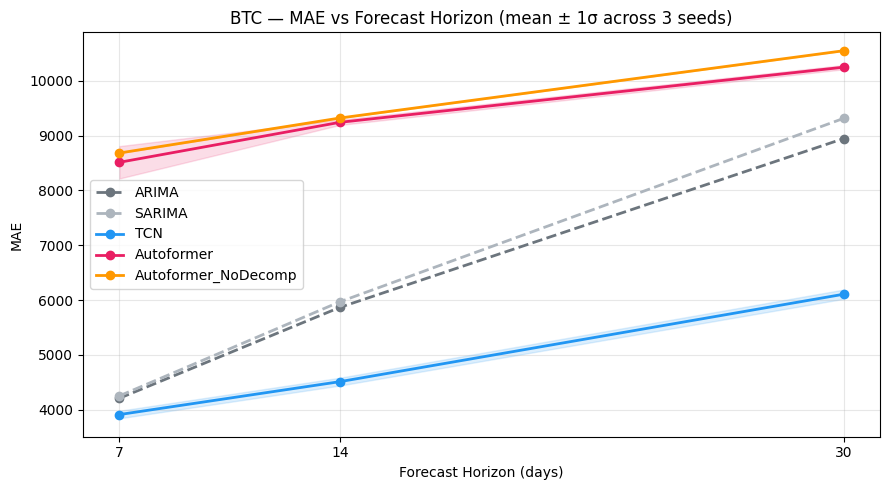

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
all_model_names = ["ARIMA", "SARIMA"] + DL_MODELS

for model in all_model_names:
    sub = master_table[master_table["Model"] == model].sort_values("h")
    if sub.empty:
        continue
    hs    = sub["h"].values
    means = sub["MAE_mean"].values
    stds  = sub["MAE_std"].values
    ls    = "--" if model in ["ARIMA", "SARIMA"] else "-"
    color = colors_used.get(model, "gray")

    ax.plot(hs, means, marker="o", label=model, color=color, linewidth=2, linestyle=ls)
    if not np.isnan(stds).all():
        ax.fill_between(hs, means - stds, means + stds, color=color, alpha=0.15)

ax.set_title(f"{DATA_SET} — MAE vs Forecast Horizon (mean ± 1σ across {len(SEEDS)} seeds)")
ax.set_xlabel("Forecast Horizon (days)")
ax.set_ylabel("MAE")
ax.set_xticks(HORIZONS)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_mae_vs_horizon_multiseed.png", dpi=150, bbox_inches="tight")
plt.show()

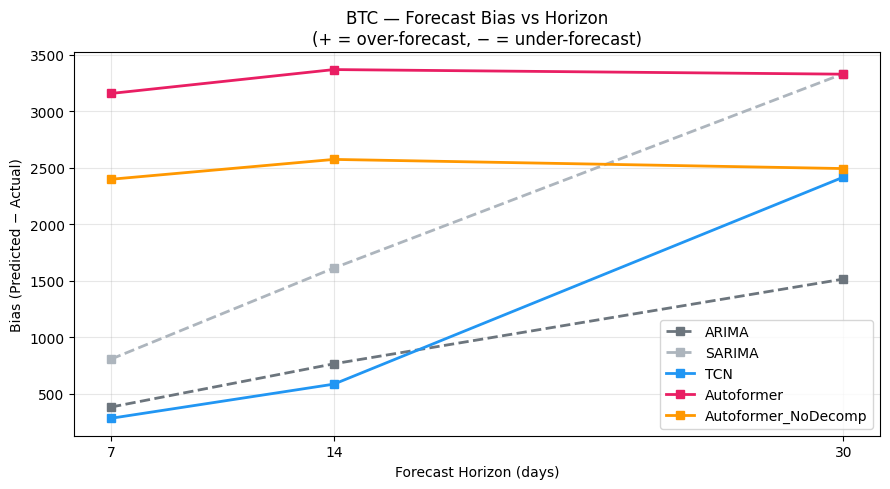

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))

for model in all_model_names:
    hs, biases = [], []
    for h in HORIZONS:
        subset = master_table[(master_table["h"] == h) & (master_table["Model"] == model)]
        if not subset.empty:
            hs.append(h)
            biases.append(subset["Bias_mean"].values[0])
    if hs:
        ls = "--" if model in ["ARIMA", "SARIMA"] else "-"
        ax.plot(hs, biases, marker="s", label=model,
                color=colors_used.get(model, "gray"), linewidth=2, linestyle=ls)

# ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title(f"{DATA_SET} — Forecast Bias vs Horizon\n"
             "(+ = over-forecast, − = under-forecast)")
ax.set_xlabel("Forecast Horizon (days)")
ax.set_ylabel("Bias (Predicted − Actual)")
ax.set_xticks(HORIZONS)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_bias_vs_horizon.png", dpi=150, bbox_inches="tight")
plt.show()



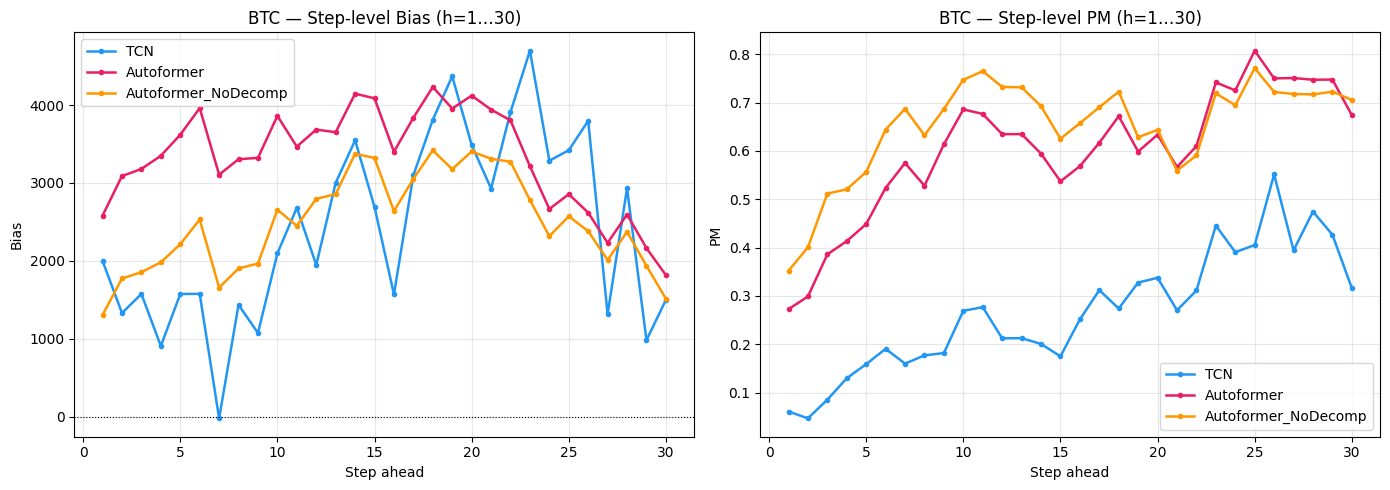

In [37]:
def dl_horizonwise_multiseed(cv_dict: dict, model_col: str, h: int) -> pd.DataFrame:
    """
    cv_dict: {seed: cv_dataframe} for a single horizon h

    For each cutoff, averages predictions across seeds first,
    then passes the seed-averaged matrix to horizonwise_errors.
    This avoids triple-weighting cutoffs that appear in multiple seeds.
    """
    # collect all unique cutoffs
    all_cuts = set()
    for cv_df in cv_dict.values():
        all_cuts.update(cv_df["cutoff"].unique())
    all_cuts = sorted(all_cuts)

    y_true_m, y_pred_m = [], []

    for cut in all_cuts:
        seed_preds = []
        y_true_ref = None

        for seed, cv_df in cv_dict.items():
            win = cv_df[cv_df["cutoff"] == cut].sort_values("ds")
            if len(win) < h or model_col not in win.columns:
                continue
            yt = win["y"].values[:h]
            yp = win[model_col].values[:h]
            if np.isnan(yt).any() or np.isnan(yp).any():
                continue
            # y_true is the same across seeds (same data, same cutoff)
            y_true_ref = yt
            seed_preds.append(yp)

        if y_true_ref is None or not seed_preds:
            continue

        # average predictions across seeds, keep one y_true row
        y_true_m.append(y_true_ref)
        y_pred_m.append(np.mean(seed_preds, axis=0))

    if not y_true_m:
        return pd.DataFrame()

    return horizonwise_errors(np.array(y_true_m), np.array(y_pred_m))


if NF_AVAILABLE and LONG_H in dl_cv_results_multiseed:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for model in DL_MODELS:
        hw = dl_horizonwise_multiseed(dl_cv_results_multiseed[LONG_H], model, LONG_H)
        if hw.empty:
            continue
        color = colors_used.get(model, "gray")
        axes[0].plot(hw["horizon"], hw["bias"], marker=".", label=model,
                     color=color, linewidth=1.8)
        axes[1].plot(hw["horizon"], hw["pm"],   marker=".", label=model,
                     color=color, linewidth=1.8)

    # overlay ARIMA / SARIMA baselines
    if "rolling_arima_results " in dir():
        axes[0].plot(rolling_arima_results ["horizon"][:LONG_H],
                     rolling_arima_results ["bias"][:LONG_H],
                     color="#6c757d", linestyle="--", label="ARIMA", linewidth=1.5)
        axes[1].plot(rolling_arima_results ["horizon"][:LONG_H],
                     rolling_arima_results ["pm"][:LONG_H],
                     color="#6c757d", linestyle="--", label="ARIMA", linewidth=1.5)
    if "rolling_sarima_results " in dir():
        axes[0].plot(rolling_sarima_results ["horizon"][:LONG_H],
                     rolling_sarima_results ["bias"][:LONG_H],
                     color="#adb5bd", linestyle="--", label="SARIMA", linewidth=1.5)
        axes[1].plot(rolling_sarima_results ["horizon"][:LONG_H],
                     rolling_sarima_results ["pm"][:LONG_H],
                     color="#adb5bd", linestyle="--", label="SARIMA", linewidth=1.5)

    axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
    axes[0].set_title(f"{DATA_SET} — Step-level Bias (h=1…{LONG_H})")
    axes[0].set_xlabel("Step ahead"); axes[0].set_ylabel("Bias")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"{DATA_SET} — Step-level PM (h=1…{LONG_H})")
    axes[1].set_xlabel("Step ahead"); axes[1].set_ylabel("PM")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"./figures/{DATA_SET}_stepwise_bias_pm.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    print(f"dl_cv_results_multiseed keys: {list(dl_cv_results_multiseed.keys())}")

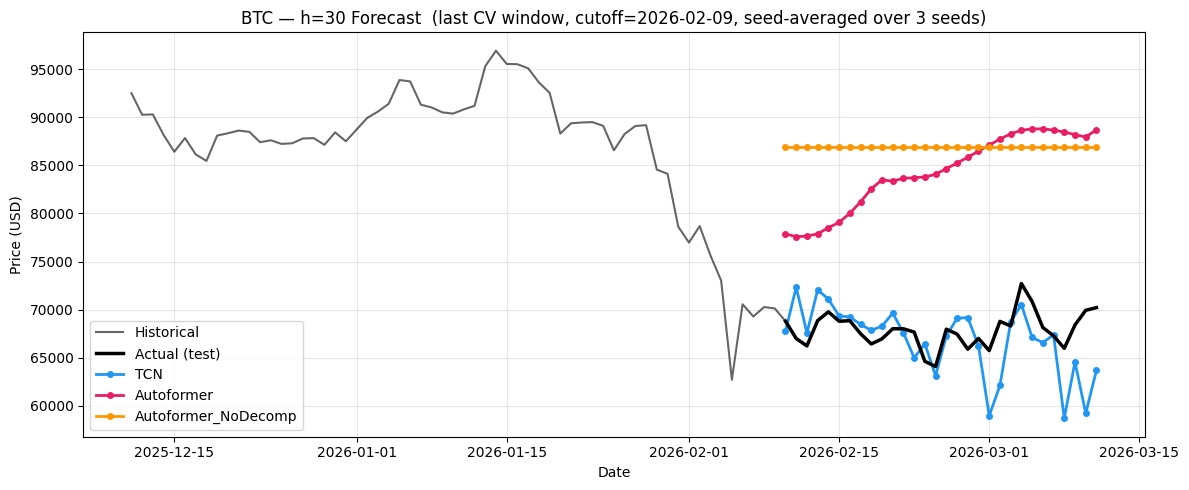

In [38]:
if NF_AVAILABLE and LONG_H in dl_cv_results_multiseed:

    # average predictions across seeds for the last cutoff
    seed_dict = dl_cv_results_multiseed[LONG_H]
    last_cut  = max(
        cv_df["cutoff"].max()
        for cv_df in seed_dict.values()
    )

    # collect per-seed windows at the last cutoff, then average predictions
    seed_windows = []
    for seed, cv_df in seed_dict.items():
        win = cv_df[cv_df["cutoff"] == last_cut].sort_values("ds")
        if len(win) >= LONG_H:
            seed_windows.append(win)

    if not seed_windows:
        print(f"No windows found at cutoff={last_cut}")
    else:
        # y_true is identical across seeds — take from the first
        base = seed_windows[0][["ds", "y"]].copy().reset_index(drop=True)

        for model in DL_MODELS:
            preds = []
            for win in seed_windows:
                if model in win.columns:
                    preds.append(win[model].values[:LONG_H])
            if preds:
                # average across seeds
                base[model] = np.mean(preds, axis=0)

        # context tail for visual continuity
        context_start = last_cut - pd.Timedelta(days=60)
        context       = df[df.index >= context_start]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(context.index, context.values,
                color="black", linewidth=1.5, label="Historical", alpha=0.6)
        ax.plot(base["ds"], base["y"],
                color="black", linewidth=2.5, label="Actual (test)", zorder=5)

        for model in DL_MODELS:
            if model in base.columns:
                ax.plot(base["ds"], base[model],
                        marker="o", markersize=4, linewidth=2,
                        label=model, color=colors_used.get(model, "gray"))

        ax.set_title(
            f"{DATA_SET} — h={LONG_H} Forecast  "
            f"(last CV window, cutoff={last_cut.date()}, "
            f"seed-averaged over {len(seed_windows)} seeds)")
        ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"./figures/{DATA_SET}_forecast_sample_h{LONG_H}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

else:
    print(f"dl_cv_results_multiseed keys: {list(dl_cv_results_multiseed.keys())}")

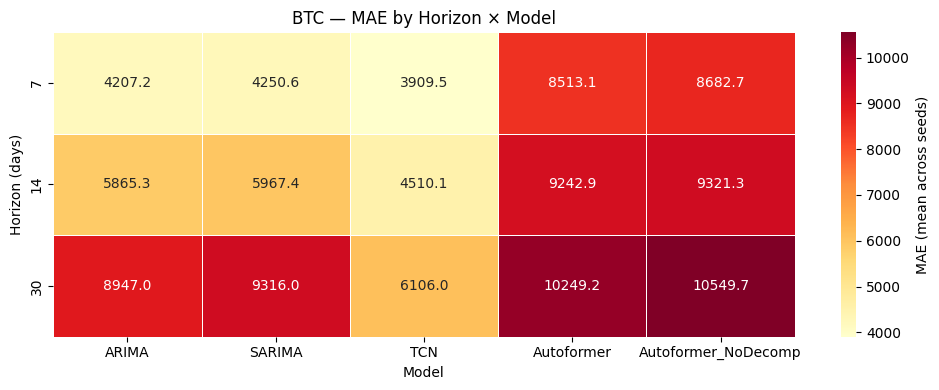

In [39]:
pivot_heatmap = master_table.pivot_table(
    index   = "h",
    columns = "Model",
    values  = "MAE_mean"
)

# order columns consistently: classical baselines first, then DL models
col_order = ["ARIMA", "SARIMA"] + [m for m in DL_MODELS if m in pivot_heatmap.columns]
pivot_heatmap = pivot_heatmap.reindex(columns=col_order)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_heatmap, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "MAE (mean across seeds)"})
ax.set_title(f"{DATA_SET} — MAE by Horizon × Model")
ax.set_xlabel("Model"); ax.set_ylabel("Horizon (days)")
plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_mae_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

  TCN kernel=2  MAE=5569.91
  TCN kernel=3  MAE=5318.50
  TCN kernel=5  MAE=7607.64
  TCN kernel=7  MAE=9990.80
   kernel_size          MAE
0            2  5569.911065
1            3  5318.498621
2            5  7607.642571
3            7  9990.800621


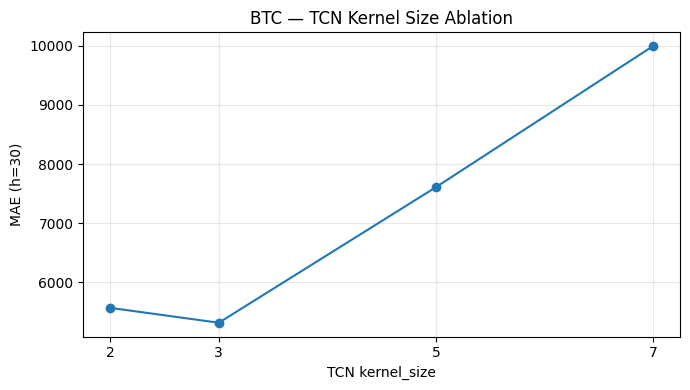

In [40]:
# TCN kernel_size ablation

kernel_sizes = [2, 3, 5, 7]
tcn_abl_rows = []

if NF_AVAILABLE:
    nf_btc = series_to_nf(DATA_SET, df)

    for k in kernel_sizes:
        model = TCN(
            h             = LONG_H,
            input_size    = INPUT_SIZE,
            kernel_size   = k,
            dilations     = [1, 2, 4, 8],   # matches Cell 6 — no hidden_size
            dropout       = 0.1,
            loss          = MAE(),
            max_steps     = MAX_STEPS,
            learning_rate = 1e-3,
            alias         = f"TCN_k{k}",
        )
        _clean_trainer_kwargs(model)            # same patcher from Cell 6

        nf_k = NeuralForecast(models=[model], freq=FREQ)
        try:
            cv_k = nf_k.cross_validation(df=nf_btc, n_windows = 3, step_size=LONG_H)
            mae  = (cv_k[f"TCN_k{k}"] - cv_k["y"]).abs().mean()
        except Exception as e:
            print(f"  TCN kernel={k} error: {e}")
            mae = np.nan
        tcn_abl_rows.append({"kernel_size": k, "MAE": mae})
        print(f"  TCN kernel={k}  MAE={mae:.2f}")

tcn_abl_df = pd.DataFrame(tcn_abl_rows)
tcn_abl_df.to_csv("./figures/tcn_kernel_ablation.csv", index=False)
print(tcn_abl_df)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tcn_abl_df["kernel_size"], tcn_abl_df["MAE"],
        marker="o")
ax.set_xlabel("TCN kernel_size")
ax.set_ylabel(f"MAE (h={LONG_H})")
ax.set_title(f"{DATA_SET} — TCN Kernel Size Ablation")
ax.set_xticks(kernel_sizes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_tcn_kernel_ablation.png", dpi=150, bbox_inches="tight")
plt.show()



  w=1  seed=1  MAE=12584.84
  w=1  seed=7  MAE=12589.16
  w=1  seed=42  MAE=12587.23
  → w=1  MAE = 12587.08 ± 2.17
  w=3  seed=1  MAE=12737.59
  w=3  seed=7  MAE=12629.64
  w=3  seed=42  MAE=12734.19
  → w=3  MAE = 12700.47 ± 61.37
  w=7  seed=1  MAE=12809.57
  w=7  seed=7  MAE=12886.26
  w=7  seed=42  MAE=12757.09
  → w=7  MAE = 12817.64 ± 64.96
  w=13  seed=1  MAE=12617.32
  w=13  seed=7  MAE=12570.32
  w=13  seed=42  MAE=12969.87
  → w=13  MAE = 12719.17 ± 218.38
  w=25  seed=1  MAE=11915.65
  w=25  seed=7  MAE=11853.62
  w=25  seed=42  MAE=12438.64
  → w=25  MAE = 12069.30 ± 321.35
  w=49  seed=1  MAE=10411.32
  w=49  seed=7  MAE=10545.71
  w=49  seed=42  MAE=10955.08
  → w=49  MAE = 10637.37 ± 283.23

Final ablation table:
   MovingAvg_window  MAE_mean  MAE_std  n_seeds
0                 1  12587.08     2.17        3
1                 3  12700.47    61.37        3
2                 7  12817.64    64.96        3
3                13  12719.17   218.38        3
4                25  

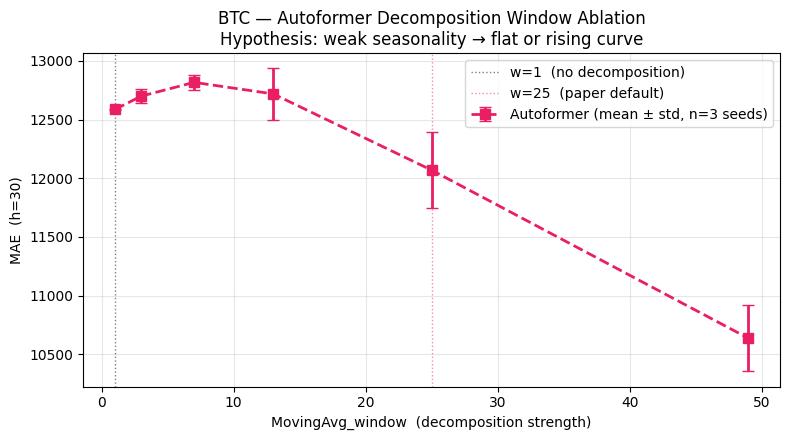

In [41]:
# Autoformer MovingAvg window ablation

decomp_kernel_sizes = [1, 3, 7, 13, 25, 49]   # odd to avoid even-window off-by-one; w=1 = no decomp
af_abl_rows = []

if NF_AVAILABLE:
    nf_btc = series_to_nf(DATA_SET, df)

    for w in decomp_kernel_sizes:
        seed_maes = []
        for s in SEEDS:
            pl.seed_everything(s, workers=True)
            model = Autoformer(
                h                = LONG_H,
                input_size       = INPUT_SIZE,
                hidden_size      = 16,
                n_head           = 2,
                encoder_layers   = 2,
                decoder_layers   = 1,
                MovingAvg_window = w,
                conv_hidden_size = 16,
                dropout          = 0.1,
                loss             = MAE(),
                max_steps        = MAX_STEPS,
                learning_rate    = 1e-3,
                alias            = f"AF_w{w}",
                random_seed      = s,
            )
            _clean_trainer_kwargs(model)
            nf_w = NeuralForecast(models=[model], freq=FREQ)
            try:
                cv_w = nf_w.cross_validation(
                    df        = nf_btc,
                    n_windows = 3,
                    step_size = LONG_H,
                )
                mae = (cv_w[f"AF_w{w}"] - cv_w["y"]).abs().mean()
            except Exception as e:
                print(f"  w={w} seed={s} error: {e}")
                mae = np.nan
            seed_maes.append(mae)
            print(f"  w={w}  seed={s}  MAE={mae:.2f}")

        seed_maes = np.array(seed_maes, dtype=float)
        af_abl_rows.append({
            "MovingAvg_window": w,
            "MAE_mean": np.nanmean(seed_maes),
            "MAE_std" : np.nanstd(seed_maes, ddof=1) if np.sum(~np.isnan(seed_maes)) > 1 else 0.0,
            "n_seeds" : int(np.sum(~np.isnan(seed_maes))),
        })
        print(f"  → w={w}  MAE = {af_abl_rows[-1]['MAE_mean']:.2f} ± {af_abl_rows[-1]['MAE_std']:.2f}")

af_abl_df = pd.DataFrame(af_abl_rows)
af_abl_df.to_csv(f"./figures/{DATA_SET}_autoformer_window_ablation.csv", index=False)
print("\nFinal ablation table:")
print(af_abl_df.round(2))

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    af_abl_df["MovingAvg_window"], af_abl_df["MAE_mean"],
    yerr=af_abl_df["MAE_std"],
    marker="s", color="#E91E63", linewidth=2, linestyle="--",
    capsize=4, markersize=7, label=f"Autoformer (mean ± std, n={len(SEEDS)} seeds)"
)
ax.axvline(x=1,  color="gray",    linewidth=1, linestyle=":", label="w=1  (no decomposition)")
ax.axvline(x=25, color="#E91E63", linewidth=1, linestyle=":", alpha=0.5, label="w=25  (paper default)")
ax.set_xlabel("MovingAvg_window  (decomposition strength)")
ax.set_ylabel(f"MAE  (h={LONG_H})")
ax.set_title(f"{DATA_SET} — Autoformer Decomposition Window Ablation\n"
             "Hypothesis: weak seasonality → flat or rising curve")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_autoformer_window_ablation.png",
            dpi=150, bbox_inches="tight")
plt.show()

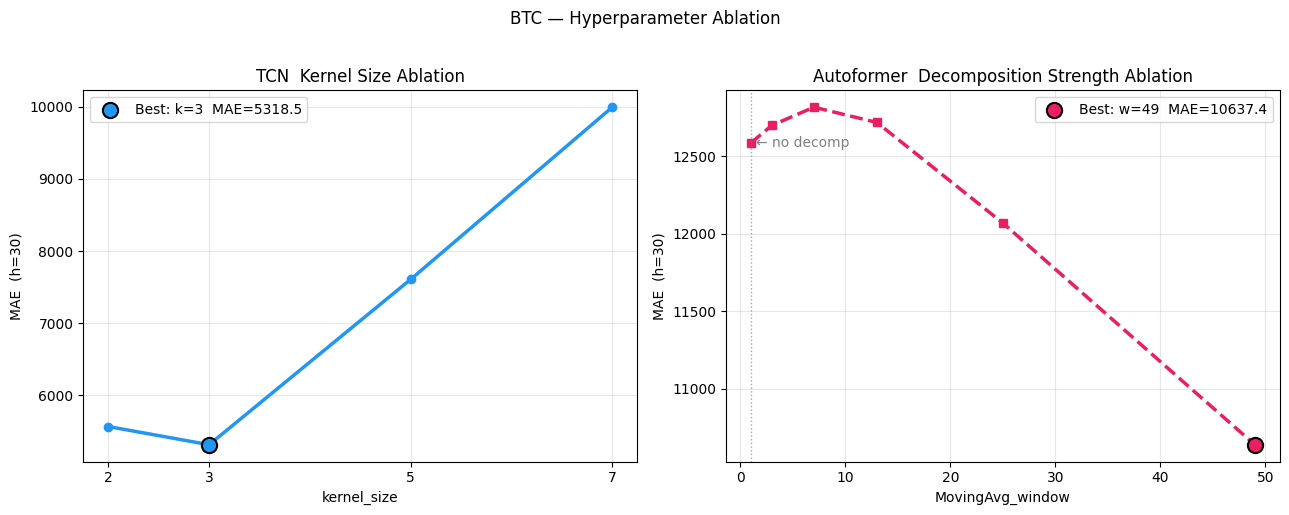

Saved → ./figures/{DATA_SET}_ablation_combined.png


In [42]:
# Combined ablation figure (TCN + Autoformer side by side)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# TCN kernel ablation
if "tcn_abl_df" in dir() and not tcn_abl_df.empty:
    axes[0].plot(tcn_abl_df["kernel_size"], tcn_abl_df["MAE"],
                 marker="o", color="#2196F3", linewidth=2.5)
    # mark the best
    best_k = tcn_abl_df.loc[tcn_abl_df["MAE"].idxmin()]
    axes[0].scatter([best_k["kernel_size"]], [best_k["MAE"]],
                    s=120, zorder=5, color="#2196F3",
                    edgecolors="black", linewidths=1.5,
                    label=f"Best: k={int(best_k['kernel_size'])}  MAE={best_k['MAE']:.1f}")
axes[0].set_xlabel("kernel_size")
axes[0].set_ylabel(f"MAE  (h={LONG_H})")
axes[0].set_title("TCN  Kernel Size Ablation")
axes[0].set_xticks(kernel_sizes)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Autoformer window ablation
if "af_abl_df" in dir() and not af_abl_df.empty:
    axes[1].plot(af_abl_df["MovingAvg_window"], af_abl_df["MAE_mean"],
                 marker="s", color="#E91E63", linewidth=2.5, linestyle="--")
    best_w = af_abl_df.loc[af_abl_df["MAE_mean"].idxmin()]
    axes[1].scatter([best_w["MovingAvg_window"]], [best_w["MAE_mean"]],
                    s=120, zorder=5, color="#E91E63",
                    edgecolors="black", linewidths=1.5,
                    label=f"Best: w={int(best_w['MovingAvg_window'])}  MAE={best_w['MAE_mean']:.1f}")
    axes[1].axvline(x=1, color="gray", linewidth=1, linestyle=":", alpha=0.7)
    axes[1].text(1.5, af_abl_df["MAE_mean"].max()*0.98, "← no decomp",
                 color="gray")
axes[1].set_xlabel("MovingAvg_window")
axes[1].set_ylabel(f"MAE  (h={LONG_H})")
axes[1].set_title("Autoformer  Decomposition Strength Ablation")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle(f"{DATA_SET} — Hyperparameter Ablation", y=1.02)
plt.tight_layout()
plt.savefig(f"./figures/{DATA_SET}_ablation_combined.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ./figures/{DATA_SET}_ablation_combined.png")



In [43]:
# Final summary print  (paste results into your report)

print("\n" + "="*65)
print(f"  FINAL RESULTS SUMMARY  —  {DATA_SET}")
print("="*65)

for h in HORIZONS:
    print(f"\n  Horizon h = {h}")
    sub = master_table[master_table["h"] == h].sort_values("MAE")
    print(sub[["Model", "MAE", "Bias", "PM"]].to_string(index=False))

best_overall = master_table.loc[master_table["MAE"].idxmin()]
print(f"\n  ── Best model overall ──")
print(f"  Model  : {best_overall['Model']}")
print(f"  Horizon: h={best_overall['h']}")
print(f"  MAE    : {best_overall['MAE']}")
print(f"  Bias   : {best_overall['Bias']}")

print("\n  Figures saved in ./figures/")
print("="*65)


  FINAL RESULTS SUMMARY  —  BTC

  Horizon h = 7
              Model             MAE            Bias        PM
                TCN  3,909.5 ± 69.0   280.8 ± 183.6 0.1 ± 0.0
              ARIMA         4,207.2           380.3       0.2
             SARIMA         4,250.6           804.8       0.2
         Autoformer 8,513.1 ± 295.4 3,157.3 ± 152.7 0.4 ± 0.0
Autoformer_NoDecomp   8,682.7 ± 0.0   2,397.5 ± 0.0 0.5 ± 0.0

  Horizon h = 14
              Model            MAE            Bias        PM
                TCN 4,510.1 ± 71.5   583.4 ± 418.1 0.2 ± 0.0
              ARIMA        5,865.3           763.4       0.3
             SARIMA        5,967.4         1,611.4       0.3
         Autoformer 9,242.9 ± 47.7 3,368.8 ± 166.3 0.5 ± 0.0
Autoformer_NoDecomp  9,321.3 ± 0.0   2,573.3 ± 0.0 0.5 ± 0.0

  Horizon h = 30
              Model             MAE            Bias        PM
         Autoformer 10,249.2 ± 38.5  3,328.0 ± 70.4 0.6 ± 0.0
Autoformer_NoDecomp  10,549.7 ± 0.0   2,492.3 ± 0.0 

In [44]:
dill.dump_session(f'{DATA_SET}_env.db')

In [45]:
!ls

BTC_env.db  drive  figures  figures_BTC  lightning_logs  sample_data


In [46]:
target_dir = CORE_PWD

# Move the 'figures_{DATA_SET}' folder
try:
  !mv figures_{DATA_SET} "{target_dir}/figures_{DATA_SET}"
  print(f"Moved 'figures_{DATA_SET}' to {target_dir}figures_{DATA_SET}")
except:
  print(f"'figures_{DATA_SET}' folder not found.")

# Move the '{DATA_SET}_env.db' file
try:
  !mv {DATA_SET}_env.db "{target_dir}/{DATA_SET}_env.db"
  print(f"Moved '{DATA_SET}_env.db' to {target_dir}{DATA_SET}_env.db")
except:
    print("'figures_{DATA_SET}.db' file not found.")

try:
  !mv figures "{target_dir}/figures"
  print(f"Moved 'figures' to {target_dir}/figures")
except:
  print("'figures' folder not found.")

Moved 'figures_BTC' to ./drive/MyDrive/GT/TSA-Decomposition/figures_BTC
Moved 'BTC_env.db' to ./drive/MyDrive/GT/TSA-Decomposition/BTC_env.db
Moved 'figures' to ./drive/MyDrive/GT/TSA-Decomposition//figures


In [47]:
from IPython.display import Javascript, display

display(Javascript("""
async function playBeeps(n) {
  for (let i = 0; i < n; i++) {
    let audio = new Audio("https://actions.google.com/sounds/v1/alarms/beep_short.ogg");
    await audio.play();
    await new Promise(r => setTimeout(r, 700));  // delay between beeps
  }
}

playBeeps(5);
"""))

<IPython.core.display.Javascript object>